In [1]:
import eos
import os
import numpy as np
import matplotlib.pyplot as plt
import ast
import cmath

colors = eos.figure.ItemColorCycler()._colors

resample = False

In [2]:
BASE_DIRECTORY = os.getcwd()
if not os.path.exists(BASE_DIRECTORY):
    os.makedirs(os.path.abspath(BASE_DIRECTORY), exist_ok=True)

In [3]:
def wstd(samples, weights=None, axis=0):
    mean_w = np.average(samples, weights=weights, axis=axis)
    return np.sqrt(np.average((samples - mean_w)**2, weights=weights, axis=axis))

def get_gof(analysis, param_array):
    parameter_list = []

    for param in analysis.init_args['priors']:
        if param['type'] == 'transform':
            parameter_list += param['parameters']
        else:
            parameter_list.append(param['parameter'])

    for i, param in enumerate(parameter_list):
        analysis.parameters.set(param, param_array[i])

    return analysis.goodness_of_fit()

In [4]:
def a11_calculator(sl_params):
    # f''/f at psi+ * coefficent + f'''/f at psi+ * coefficent
    return sl_params[0] * (-0.365625798636340) + sl_params[1] * 0.065122863429160

def charge_radius_squared_calculator(fprime_values):
    # 6 * df/dpsi at psi(0) * dpsi/ds at s=0 * (hbar c)^2
    return 6 * fprime_values * (-1.31241754914090000000) * (0.19732697178003900000)**2 #fm^2

In [5]:
def get_f_rho(sample, ana):
    get_gof(ana, sample)
    s_rho = (sample[0] - 1j * sample[1] / 2)**2
    return [eos.Observable.make("0->pipi::Re{f_+}(Re{q2},Im{q2})",
                        ana.parameters,
                        eos.Kinematics({"Re{q2}": np.real(s_rho), "Im{q2}": np.imag(s_rho)}),
                        eos.Options({'form-factors': "BHKMNR2026", "n-resonances": '1'})).evaluate(),
            eos.Observable.make("0->pipi::Im{f_+}(Re{q2},Im{q2})",
                        ana.parameters,
                        eos.Kinematics({"Re{q2}": np.real(s_rho), "Im{q2}": np.imag(s_rho)}),
                        eos.Options({'form-factors': "BHKMNR2026", "n-resonances": '1'})).evaluate()]

def get_f_bfp(ana, bfp, q2):
    get_gof(ana, bfp)
    return eos.Observable.make("0->pipi::Abs{f_+}^2(q2)",
                        ana.parameters,
                        eos.Kinematics({'q2': q2}),
                        eos.Options({'form-factors': "BHKMNR2026", "n-resonances": '1'})).evaluate()

def get_f_arg_bfp(ana, bfp, q2):
    get_gof(ana, bfp)
    return eos.Observable.make("0->pipi::Arg{f_+}(q2)",
                        ana.parameters,
                        eos.Kinematics({'q2': q2}),
                        eos.Options({'form-factors': "BHKMNR2026", "n-resonances": '1'})).evaluate()

def get_f_arg_of_psi_bfp(ana, bfp, psi):
    get_gof(ana, bfp)
    return eos.Observable.make("0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026",
                        ana.parameters,
                        eos.Kinematics({'Re{psi}': np.real(psi), 'Im{psi}': np.imag(psi)}),
                        eos.Options({'form-factors': "BHKMNR2026", "n-resonances": '1'})).evaluate()

def get_f_abs_of_psi_bfp(ana, bfp, psi):
    get_gof(ana, bfp)
    return eos.Observable.make("0->pipi::Abs{f_+}^2(Re{psi},Im{psi})@BHKMNR2026",
                        ana.parameters,
                        eos.Kinematics({'Re{psi}': np.real(psi), 'Im{psi}': np.imag(psi)}),
                        eos.Options({'form-factors': "BHKMNR2026", "n-resonances": '1'})).evaluate()

In [6]:
mpi    = eos.Parameters()["mass::pi^+"].evaluate()
sPlus  = 4 * mpi**2
sMinus = 0.0
sIn    = 0.85051 #pi-omega threshold

In [7]:
def phi_11(s: complex) -> complex:
        return (cmath.sqrt(sIn - s) - cmath.sqrt(sIn - sPlus)) / cmath.sqrt(sPlus - s)

def phi_21(s: complex) -> complex:
        return -phi_11(s)

phi_L = phi_21(sMinus)
phi_0 = phi_11(sMinus)

In [8]:
def chi(x: complex) -> complex:

    A = (x * (phi_L -1)**2 - phi_L * (x - 1)**2) * (phi_0 - 1)**2
    B = (phi_0 * (phi_L -1)**2 - phi_L * (phi_0- 1)**2) * (x - 1)**2

    sqrtA = cmath.sqrt(A)
    sqrtB = cmath.sqrt(B)

    return (sqrtA - sqrtB) / (sqrtA + sqrtB)


def phi_to_psi(phi: complex) -> complex:

    if abs(phi) <= 1:
        return chi(phi)
    else:
        return 1.0 / chi(1.0 / phi)


def chi_inv(y: complex) -> complex:

    A = (y - 1)**2 * (phi_L - 1)**2 * (phi_0 - 1)**2
    B = 4 * phi_0 * (y + 1)**2 * (phi_L - 1)**2 - 16 * y * phi_L * (phi_0 - 1)**2

    sqrtA  = cmath.sqrt(A)
    sqrtAB = cmath.sqrt(A + B)

    return (sqrtAB - sqrtA) / (sqrtAB + sqrtA)


def psi_to_phi(psi: complex) -> complex:

    if abs(psi) <= 1:
        return chi_inv(psi)
    else:
        return 1.0 / chi_inv(1.0 / psi)


def phi_to_s(phi: complex) -> complex:
        return (sPlus * (1 + phi**2)**2 - 4 * sIn * phi**2) / ((1 - phi**2)**2)


In [9]:
def is_on_11_sheet(psi: complex) -> bool:

    phi = psi_to_phi(psi)
    return abs(phi) < 1.0 and phi.real > 0

def has_no_roots_on_11_sheet(a: list[float]) -> bool:

    roots = np.polynomial.polynomial.polyroots(a)
    return not any(is_on_11_sheet(r) for r in roots)

In [10]:
af = eos.AnalysisFile(os.path.join(os.getcwd(), 'analysis.yaml'))

In [11]:
dense = np.linspace(-sPlus, sPlus, 40)
left = np.linspace(-2.5, -sPlus, 61)[:-1]
right = np.linspace(sPlus, 2.5, 61)[1:]
sparse = np.concatenate([left, right])

q2_vals = np.concatenate([dense, sparse])
q2_vals.sort()

result = [{'q2': float(v)} for v in q2_vals]

In [12]:
result

[{'q2': -2.5},
 {'q2': -2.4596319929176502},
 {'q2': -2.4192639858353004},
 {'q2': -2.3788959787529502},
 {'q2': -2.3385279716706004},
 {'q2': -2.2981599645882507},
 {'q2': -2.257791957505901},
 {'q2': -2.217423950423551},
 {'q2': -2.177055943341201},
 {'q2': -2.136687936258851},
 {'q2': -2.0963199291765013},
 {'q2': -2.0559519220941516},
 {'q2': -2.015583915011802},
 {'q2': -1.9752159079294518},
 {'q2': -1.934847900847102},
 {'q2': -1.894479893764752},
 {'q2': -1.8541118866824022},
 {'q2': -1.8137438796000525},
 {'q2': -1.7733758725177025},
 {'q2': -1.7330078654353527},
 {'q2': -1.6926398583530027},
 {'q2': -1.652271851270653},
 {'q2': -1.6119038441883031},
 {'q2': -1.5715358371059533},
 {'q2': -1.5311678300236033},
 {'q2': -1.4907998229412536},
 {'q2': -1.4504318158589036},
 {'q2': -1.4100638087765538},
 {'q2': -1.369695801694204},
 {'q2': -1.329327794611854},
 {'q2': -1.2889597875295042},
 {'q2': -1.2485917804471542},
 {'q2': -1.2082237733648045},
 {'q2': -1.1678557662824547},
 {'q2

In [13]:
dense = np.linspace(-0.01, 0.01, 200)
left = np.linspace(-2.5, -0.01, 61)[:-1]
right = np.linspace(0.01, 2.5, 61)[1:]
sparse = np.concatenate([left, right])
q2_vals = np.concatenate([dense, sparse])

q2_vals.sort()

result = [{'q2': float(v)} for v in q2_vals]

In [14]:
result

[{'q2': -2.5},
 {'q2': -2.4585},
 {'q2': -2.417},
 {'q2': -2.3755},
 {'q2': -2.334},
 {'q2': -2.2925},
 {'q2': -2.251},
 {'q2': -2.2095},
 {'q2': -2.168},
 {'q2': -2.1265},
 {'q2': -2.085},
 {'q2': -2.0435},
 {'q2': -2.002},
 {'q2': -1.9605000000000001},
 {'q2': -1.919},
 {'q2': -1.8775},
 {'q2': -1.8359999999999999},
 {'q2': -1.7945},
 {'q2': -1.7530000000000001},
 {'q2': -1.7115},
 {'q2': -1.67},
 {'q2': -1.6284999999999998},
 {'q2': -1.587},
 {'q2': -1.5455},
 {'q2': -1.504},
 {'q2': -1.4625},
 {'q2': -1.421},
 {'q2': -1.3795},
 {'q2': -1.3379999999999999},
 {'q2': -1.2965},
 {'q2': -1.255},
 {'q2': -1.2135},
 {'q2': -1.172},
 {'q2': -1.1304999999999998},
 {'q2': -1.089},
 {'q2': -1.0474999999999999},
 {'q2': -1.006},
 {'q2': -0.9644999999999999},
 {'q2': -0.9229999999999998},
 {'q2': -0.8815},
 {'q2': -0.8399999999999999},
 {'q2': -0.7985},
 {'q2': -0.7569999999999999},
 {'q2': -0.7154999999999998},
 {'q2': -0.6739999999999999},
 {'q2': -0.6324999999999998},
 {'q2': -0.591},
 {'q2'

## 0 -> pi pi order 8

In [167]:
posterior = 'FF-fp-I1-order8'
analysis  = af.analysis(posterior)

Creating analysis with 7 priors, 3 EOS-wide constraints, 2 global options, 2 manually-entered constraints and 2 fixed parameters.
likelihood probably depends on 10 parameter(s) that do not appear in the prior; check prior?


In [183]:
start_point = [ 0.76134062,  0.14494169,  0.0977501 , -0.20824488,  0.06846099,
       -0.10047329, -0.00706721]

In [184]:
get_gof(analysis, start_point)

In [182]:
#bfp, gof = eos.tasks.find_mode(af, posterior, start_point=start_point, base_directory=BASE_DIRECTORY, optimizations=100)
bfp, gof = eos.tasks.find_mode(af, posterior, importance_samples=True, base_directory=BASE_DIRECTORY, optimizations=100)
display(gof)
bfp.point

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8/mo…

array([ 0.76134062,  0.14494169,  0.0977501 , -0.20824488,  0.06846099,
       -0.10047329, -0.00706721])

In [168]:
if resample:
    eos.tasks.sample_nested(af, posterior, base_directory=BASE_DIRECTORY, bound='multi', nlive=200)

f = eos.data.ImportanceSamples(os.path.join(BASE_DIRECTORY, 'data', posterior, 'samples'))
print(f"Collected {f.samples.shape[0]} samples")

Collected 15185 samples


In [169]:
for i, p in enumerate(analysis.varied_parameters):
    mean = np.average(f.samples[:,i], weights=f.weights)
    std  = wstd(f.samples[:,i], weights=f.weights)
    print(f"      - {{ 'parameter': '{p.name()}', 'min':  {mean - 5*std:.5f}, 'max':  {mean + 5*std:.5f}, 'type': 'uniform'}}")

      - { 'parameter': '0->pipi::M_(+,1,0)@BHKMNR2026', 'min':  0.75968, 'max':  0.76330, 'type': 'uniform'}
      - { 'parameter': '0->pipi::Gamma_(+,1,0)@BHKMNR2026', 'min':  0.14151, 'max':  0.14873, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^4@BHKMNR2026', 'min':  -0.00662, 'max':  0.24639, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^5@BHKMNR2026', 'min':  -0.35790, 'max':  -0.03046, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^6@BHKMNR2026', 'min':  -0.03724, 'max':  0.22628, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^7@BHKMNR2026', 'min':  -0.17326, 'max':  -0.02168, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^8@BHKMNR2026', 'min':  -0.04759, 'max':  0.05463, 'type': 'uniform'}


Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8/pl…

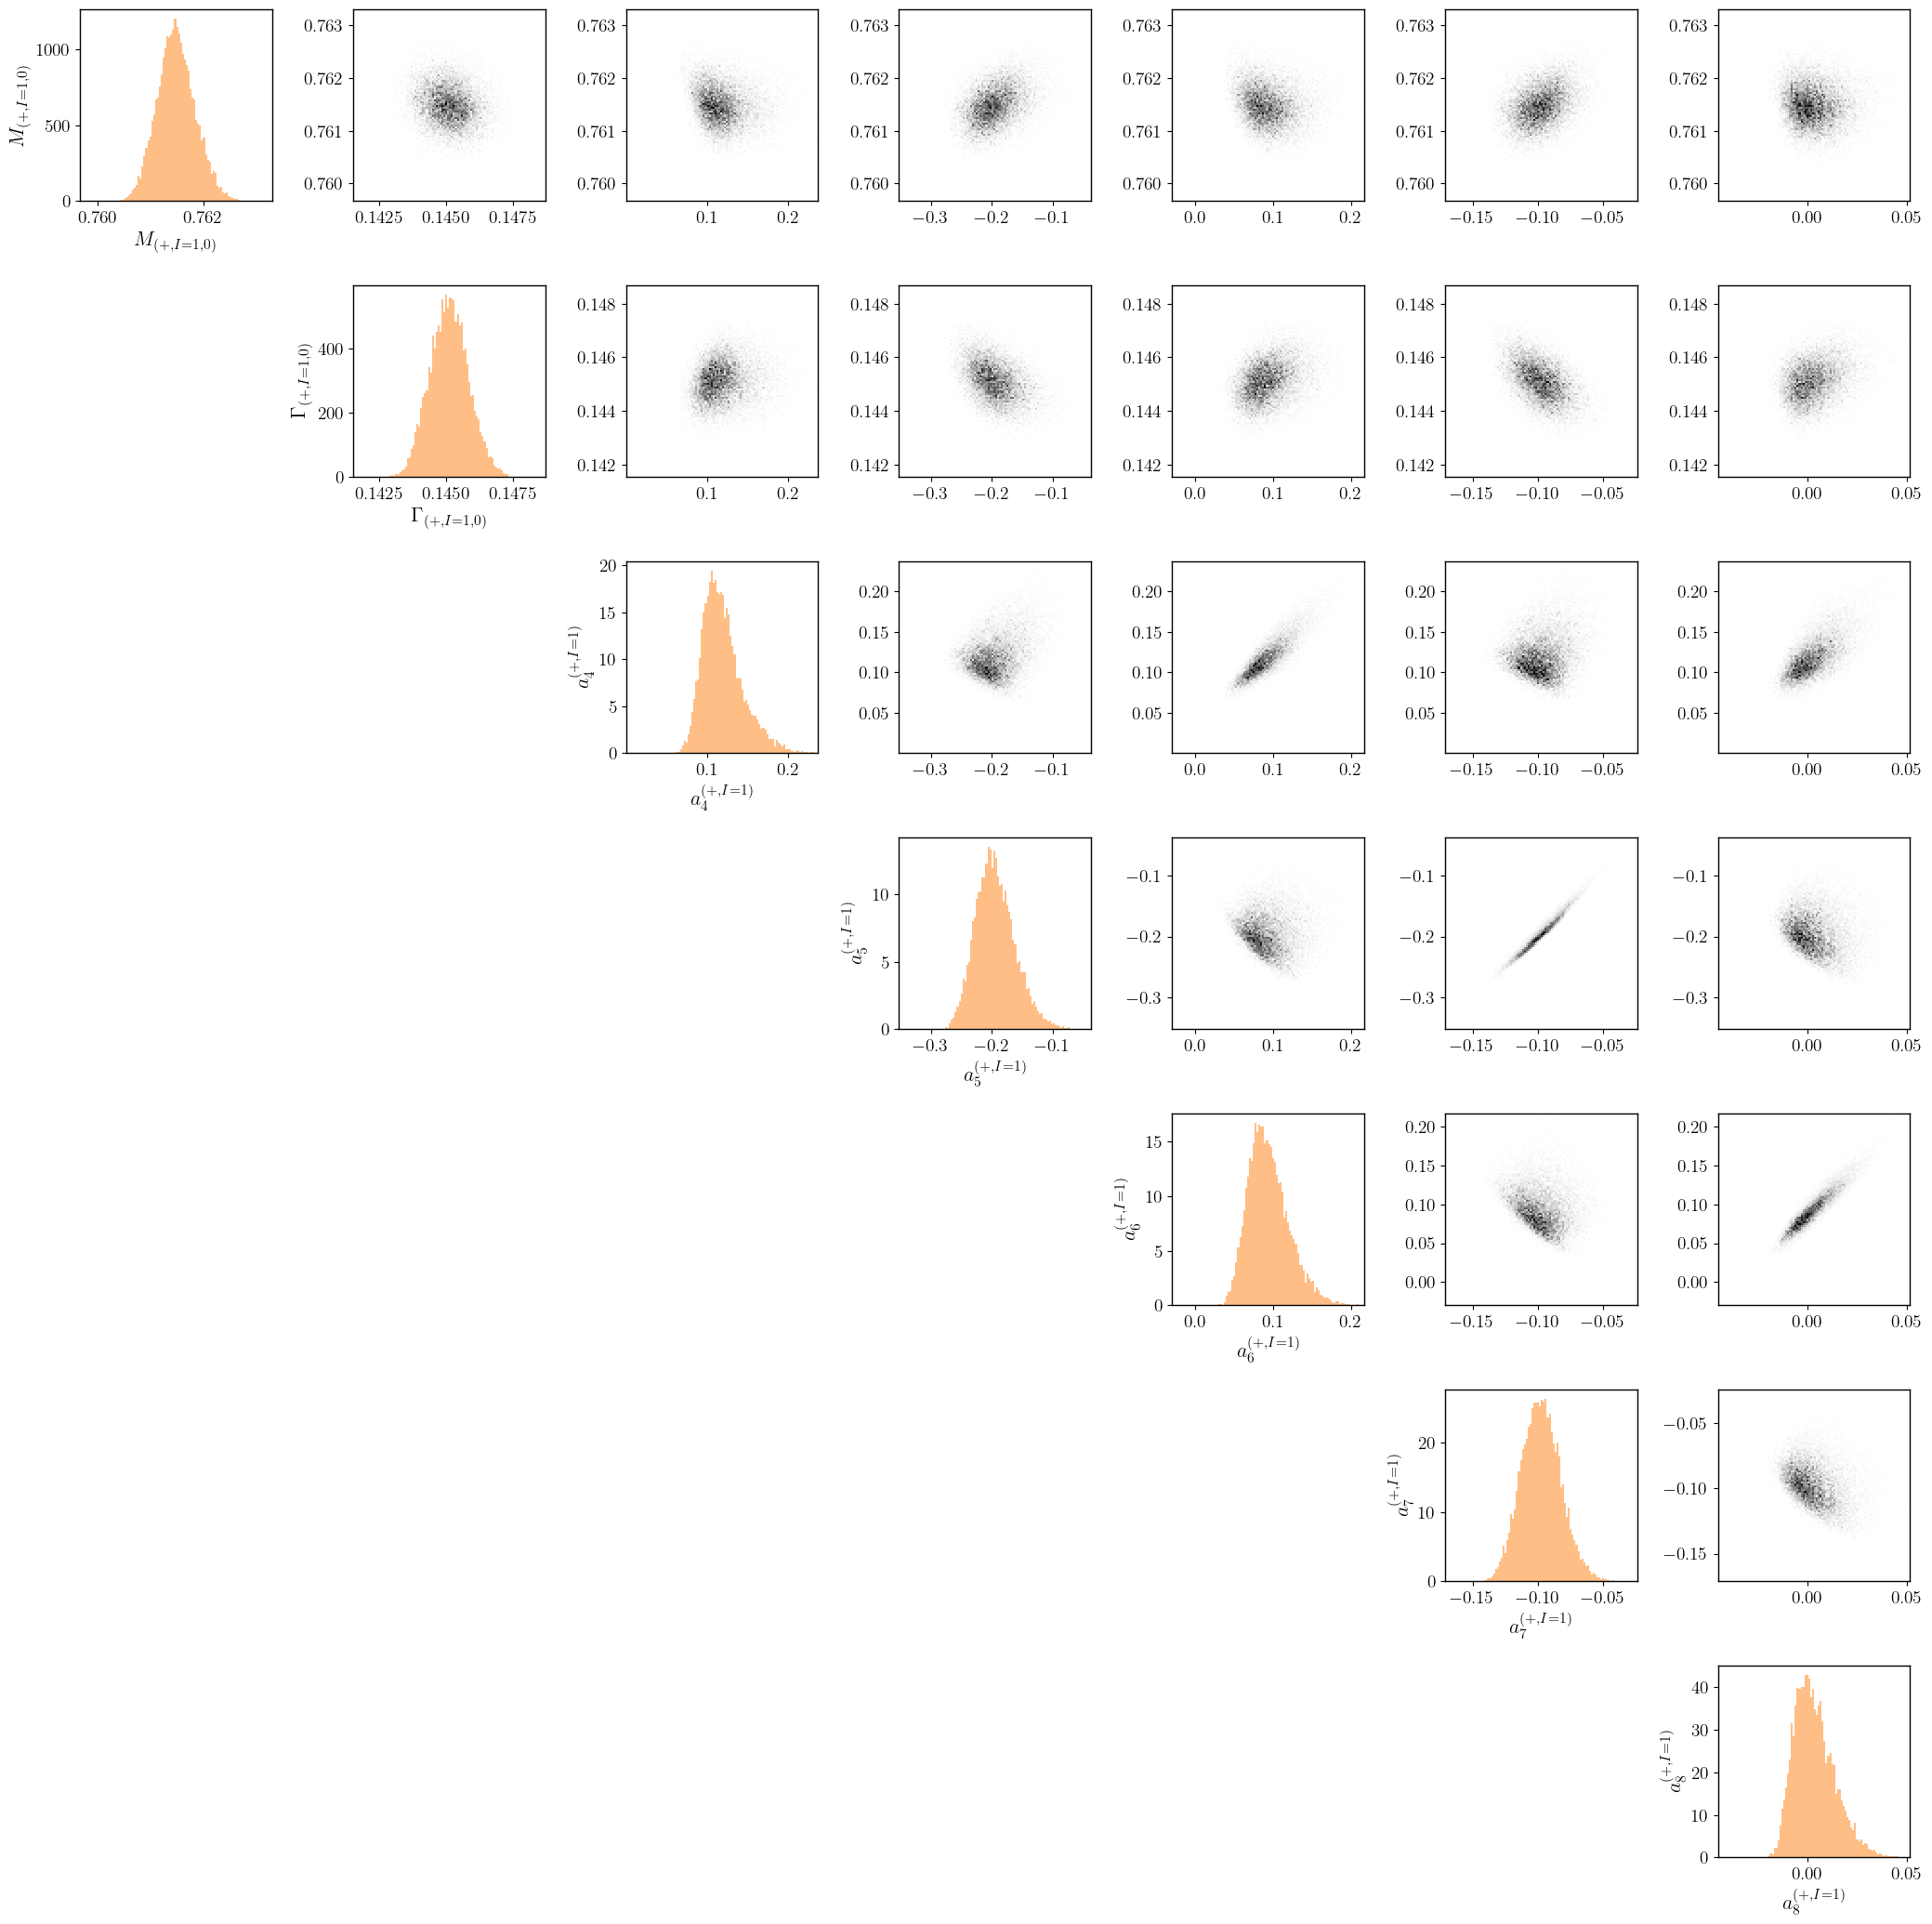

In [170]:
eos.tasks.corner_plot(af, posterior, base_directory=BASE_DIRECTORY)

In [171]:
print(f"rho mass  = {np.average(f.samples[:,0], weights=f.weights):.4f} ± {wstd(f.samples[:,0], weights=f.weights):.4f}")
print(f"rho width = {np.average(f.samples[:,1], weights=f.weights):.4f} ± {wstd(f.samples[:,1], weights=f.weights):.4f}")

rho mass  = 0.7615 ± 0.0004
rho width = 0.1451 ± 0.0007


In [172]:
# Dispersive bound computation
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-dispersive-bound", base_directory=BASE_DIRECTORY)
preds = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-dispersive-bound'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8/pr…

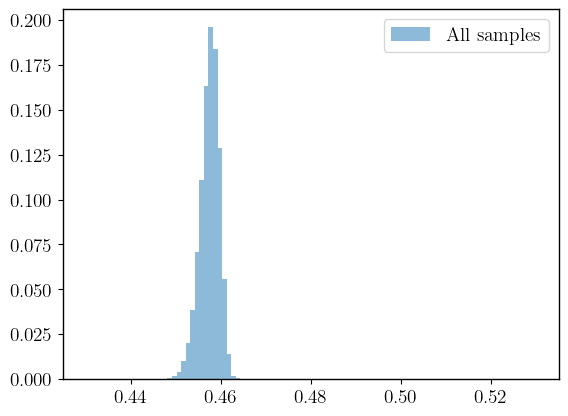

In [173]:
plt.hist(preds.samples, weights=preds.weights, bins=np.linspace(0.43,0.53,100), alpha=0.5, label='All samples')
plt.legend()
plt.show()

In [174]:
disp_values = np.array(preds.samples[:,0])
disp_mean   = np.average(disp_values, weights=preds.weights)
disp_std    = wstd(disp_values, weights=preds.weights)
print(f"Dispersive bound is {disp_mean:.4f} ± {disp_std:.4f}")

Dispersive bound is 0.4575 ± 0.0021


In [175]:
eos.tasks.predict_observables(af, posterior, "FF-fp2-I1-all", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8/pr…

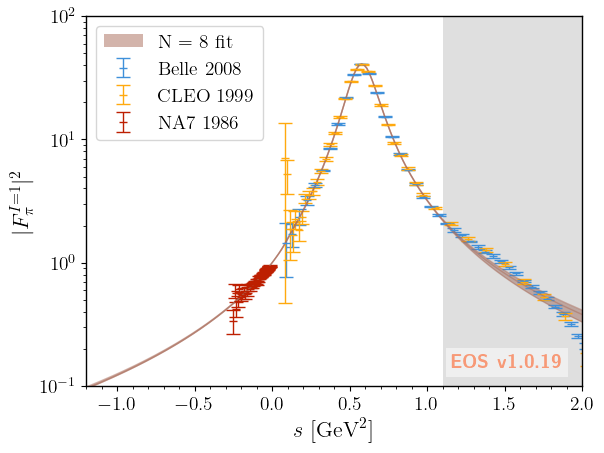

In [176]:
figure_args = {
'watermark': { 'position': 'lower right' },
'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-1.2, 2.0] },
    'yaxis': { 'label': r'$|F^{I=1}_\pi|^2$', 'range': [ 0.1, 100.0], 'scale': 'log' },
    'legend': { 'position': 'upper left' },
    'items': [
    { 'type': 'constraint', 'label': 'Belle 2008', 'color': colors[0],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2)',
        'constraints': '0->pipi::Abs{f_+}^2@Belle:2008C',
    },
    { 'type': 'constraint', 'label': 'CLEO 1999', 'color': colors[1],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2)',
        'constraints': '0->pipi::Abs{f_+}^2@CLEO:2000B',
    },
    { 'type': 'constraint', 'label': 'NA7 1986', 'color': colors[2],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2)',
        'constraints': '0->pipi::Abs{f_+}^2@NA7:1986A',
    },
    { 'type': 'uncertainty', 'label': 'N = 8 fit', 'color': colors[5],
        'variable': 'q2', 'range': [-1.2, 2.0], 'interpolation': 'cubic',
        'datafile': 'data/'+posterior+'/pred-FF-fp2-I1-all', 'resolution': 300
    },
    { 'type': 'band', 'color': 'gray', 'alpha': 0.25, 'x': [1.1, 2.0], 'y': [0.0, 100]}
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [177]:
eos.tasks.predict_observables(af, posterior, "FF-arg-fp-I1-timelike", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8/pr…

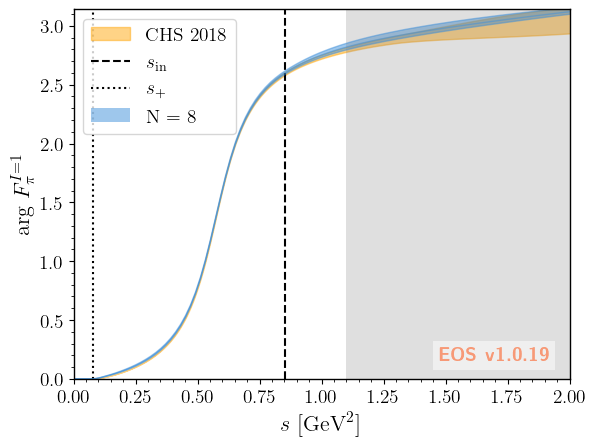

In [178]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [0.0, 2.0] },
    'yaxis': { 'label': r'arg $F^{I=1}_\pi$', 'range': [0.0 , np.pi] },
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'N = 8', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-FF-arg-fp-I1-timelike', 'color': colors[0]
      },
      { 'type': 'band', 'color': 'gray', 'alpha': 0.25, 'x': [1.1, 2.0], 'y': [0.0, np.pi]}
    ]
  }
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)

q2_over_mpisquared, phase, err = np.loadtxt("scripts/d11-central.txt", skiprows=1, unpack=True)
mpi = eos.Parameters()["mass::pi^+"].evaluate()
q2  = q2_over_mpisquared * mpi**2

figure._ax.fill_between(q2, phase-err, phase+err, label="CHS 2018", alpha=0.5, color=colors[1])
figure._ax.plot([sIn, sIn], [0.0, np.pi], color='k', linestyle='--', label= r'$s_\mathrm{in}$')
figure._ax.plot([sPlus, sPlus], [0.0, np.pi], color='k', linestyle=':', label= r'$s_+$')
figure._ax.legend(loc="upper left")

figure.draw()

In [185]:
get_gof(analysis, start_point)
analysis.parameters.dump('data/'+posterior+'/mode-default/parameters.yaml')

Handling item to plot 0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026 in the complex plane
Overriding parameters from file
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,2)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(0,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(0,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,2)@KSvD2025' with central value '0'
[parameters.override] Overriding existing p

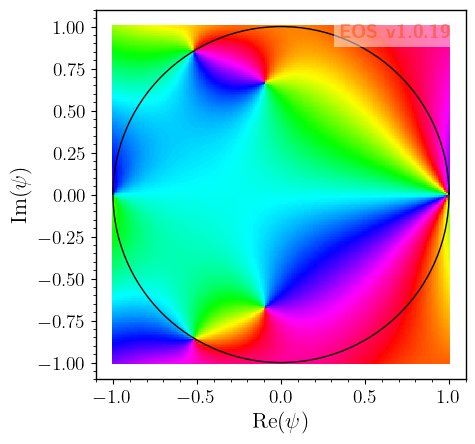

In [186]:
figure_args = {
'plot': {
    'xaxis': { 'label': r'$\mathrm{Re}(\psi)$', 'range': [-1.1, 1.1] },
    'yaxis': { 'label': r'$\mathrm{Im}(\psi)$', 'range': [-1.1, 1.1] },
    # 'legend': { 'position': 'upper left' },
    'items': [
    { 'type': 'complex-plane', 'label': 'N = 8 fit', 'colormap': 'hsv',
        'variables': ["Re{psi}", "Im{psi}"], 'observable': "0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026",
        'fixed_parameters_from_file': 'data/'+posterior+'/mode-default/parameters.yaml', 'resolution': 200
    }
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()
circle = plt.Circle((0, 0), 1.0, color='k', fill=False)
figure._ax.add_patch(circle)
figure._ax.set_aspect("equal", adjustable="box")

In [187]:
eos.tasks.predict_observables(af, posterior, "real-partial-wave-I1", base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables(af, posterior, "imag-partial-wave-I1", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8/pr…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8/pr…

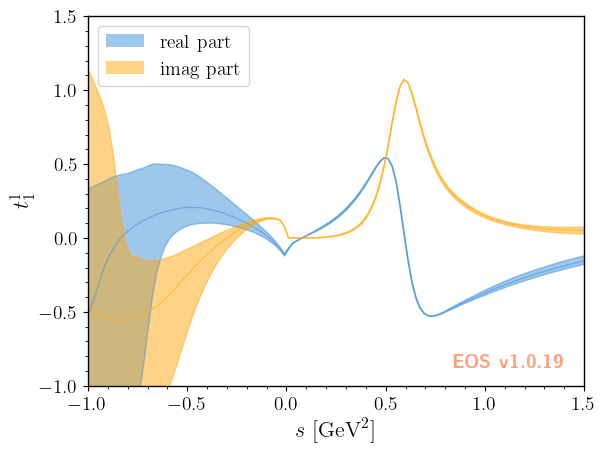

In [ ]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-2.5, 2.5] },
    'yaxis': { 'label': '$t_1^1$', 'range': [-1.0, 1.0]},
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'real part', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-real-partial-wave-I1'
      },
      { 'type': 'uncertainty', 'label': 'imag part', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-imag-partial-wave-I1'
      },
    ]
  }
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

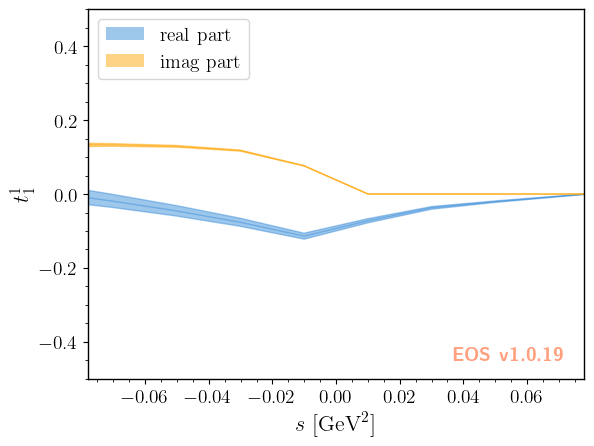

In [189]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-sPlus, sPlus] },
    'yaxis': { 'label': '$t_1^1$', 'range': [-0.5, 0.5]},
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'real part', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-real-partial-wave-I1'
      },
      { 'type': 'uncertainty', 'label': 'imag part', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-imag-partial-wave-I1'
      },
    ]
  }
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [190]:
# Analytic value of a11
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-scattering-length-params", base_directory=BASE_DIRECTORY)
sl_params = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-scattering-length-params'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8/pr…

In [191]:
a11_values = np.array(list(map(a11_calculator, sl_params.samples))) * mpi**2
a11_mean   = np.average(a11_values, weights=sl_params.weights)
a11_std    = wstd(a11_values, weights=sl_params.weights)
print(f"a11 = {a11_mean:.4f} ± {a11_std:.4f}")

a11 = 0.0147 ± 0.0012


In [192]:
# Charge radius
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-pion-charge-radius-param", base_directory=BASE_DIRECTORY)
fprime_values = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-pion-charge-radius-param'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8/pr…

In [193]:
charge_radius_squared_values = np.array(list(map(charge_radius_squared_calculator, fprime_values.samples[:, 0])))
radius_mean = np.average(charge_radius_squared_values, weights=fprime_values.weights)
radius_std  = wstd(charge_radius_squared_values, weights=fprime_values.weights)
print(f"<r^2> = {radius_mean:.4f} ± {radius_std:.4f} fm^2")

<r^2> = 0.4268 ± 0.0035 fm^2


In [194]:
# Residue at the rho pole
eos.tasks.predict_observables(af, posterior, "re-rho-residue-psi", base_directory=BASE_DIRECTORY)
re_res_psi = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-re-rho-residue-psi'))
eos.tasks.predict_observables(af, posterior, "im-rho-residue-psi", base_directory=BASE_DIRECTORY)
im_res_psi = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-im-rho-residue-psi'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8/pr…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8/pr…

In [195]:
re_res = re_res_psi.samples[:,0]
im_res = im_res_psi.samples[:,0]
M      = f.samples[:,0]
Gamma  = f.samples[:,1]

print(len(re_res), len(im_res), len(M), len(Gamma)) # check that they have the same length

15185 15185 15185 15185


In [196]:
data = []

for r, i, m, g in zip(re_res, im_res, M, Gamma):
    data.append([r, i, m, g])
with open("residues_psi_order8.wl", "w") as file:
    lines = [f"{{{r}, {i}, {m}, {g}}}" for r, i, m, g in data]
    file.write("{\n" + ",\n".join(lines) + "\n}")

In [108]:
with open("residues_s_order8.wl") as file:
    text = file.read()

# Replace Mathematica braces with Python brackets
text = text.replace("{", "[").replace("}", "]")

data = ast.literal_eval(text)

In [109]:
res_s       = np.array([re + 1j * im for re, im in data])
res_s_mean  = np.average(res_s, weights=f.weights)
radius_std  = wstd(res_s, weights=f.weights)
print(f"residue at s_rho is ({np.real(res_s_mean):.4f} ± {np.real(radius_std):.4f}) + i * ({np.imag(res_s_mean):.4f} ± {np.imag(radius_std):.4f})")

residue at s_rho is (-0.7516 ± 0.0066) + i * (0.3342 ± 0.0133)


In [110]:
# Computing g_{rho pi pi} and g_{rho gamma}
f_at_s_rho       = np.array([get_f_rho(s, analysis) for s in f.samples])
f_at_s_rho_value = f_at_s_rho[:,0] + 1j * f_at_s_rho[:,1]

In [111]:
s_rho       = (M - 1j * Gamma / 2)**2
g_rho_gamma = np.sqrt(24j * np.pi * s_rho / f_at_s_rho_value / res_s / (np.sqrt(1 - sPlus / s_rho))**3)
g_rho_pi_pi = (- res_s / s_rho) * g_rho_gamma

In [112]:
g_rho_gamma_mean = np.average(g_rho_gamma, weights=f.weights)
g_rho_gamma_std  = wstd(g_rho_gamma, weights=f.weights)
print(f"g_rho_gamma =  ({np.real(g_rho_gamma_mean):.4f} ± {np.real(g_rho_gamma_std):.4f}) + i * ({np.imag(g_rho_gamma_mean):.4f} ± {np.imag(g_rho_gamma_std):.4f})")

g_rho_pi_pi_mean = np.average(g_rho_pi_pi, weights=f.weights)
g_rho_pi_pi_std  = wstd(g_rho_pi_pi, weights=f.weights)
print(f"g_rho_pi_pi =  ({np.real(g_rho_pi_pi_mean):.4f} ± {np.real(g_rho_pi_pi_std):.4f}) + i * ({np.imag(g_rho_pi_pi_mean):.4f} ± {np.imag(g_rho_pi_pi_std):.4f})")

g_rho_gamma =  (4.5310 ± 0.0008) + i * (0.1974 ± -0.0060)
g_rho_pi_pi =  (6.2873 ± 0.0225) + i * (-1.1779 ± 0.0992)


## 0 -> pi pi order 9


In [210]:
posterior = 'FF-fp-I1-order9'
analysis  = af.analysis(posterior)

Creating analysis with 8 priors, 3 EOS-wide constraints, 2 global options, 2 manually-entered constraints and 2 fixed parameters.
likelihood probably depends on 9 parameter(s) that do not appear in the prior; check prior?


In [222]:
start_point = [0.76139661,  0.14511054,  0.09414805, -0.208473  ,  0.068799  ,
       -0.09357161, -0.00618338,  0.00479719]

In [223]:
get_gof(analysis, start_point)

In [221]:
bfp, gof = eos.tasks.find_mode(af, posterior, start_point=start_point, base_directory=BASE_DIRECTORY, optimizations=100)
#bfp, gof = eos.tasks.find_mode(af, posterior, importance_samples=True, base_directory=BASE_DIRECTORY, optimizations=100)
display(gof)
bfp.point

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9/mo…

array([ 0.76139661,  0.14511054,  0.09414805, -0.208473  ,  0.068799  ,
       -0.09357161, -0.00618338,  0.00479719])

In [211]:
if resample:
    eos.tasks.sample_nested(af, posterior, base_directory=BASE_DIRECTORY, bound='multi', nlive=200)

f = eos.data.ImportanceSamples(os.path.join(BASE_DIRECTORY, 'data', posterior, 'samples'))
print(f"Collected {f.samples.shape[0]} samples")

Collected 16661 samples


In [212]:
for i, p in enumerate(analysis.varied_parameters):
    mean = np.average(f.samples[:,i], weights=f.weights)
    std  = wstd(f.samples[:,i], weights=f.weights)
    print(f"      - {{ 'parameter': '{p.name()}', 'min':  {mean - 5*std:.5f}, 'max':  {mean + 5*std:.5f}, 'type': 'uniform'}}")

      - { 'parameter': '0->pipi::M_(+,1,0)@BHKMNR2026', 'min':  0.75968, 'max':  0.76341, 'type': 'uniform'}
      - { 'parameter': '0->pipi::Gamma_(+,1,0)@BHKMNR2026', 'min':  0.14148, 'max':  0.14885, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^4@BHKMNR2026', 'min':  -0.02602, 'max':  0.27545, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^5@BHKMNR2026', 'min':  -0.39388, 'max':  0.02226, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^6@BHKMNR2026', 'min':  -0.04761, 'max':  0.24765, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^7@BHKMNR2026', 'min':  -0.25399, 'max':  0.07253, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^8@BHKMNR2026', 'min':  -0.05020, 'max':  0.06160, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^9@BHKMNR2026', 'min':  -0.05910, 'max':  0.06395, 'type': 'uniform'}


Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9/pl…

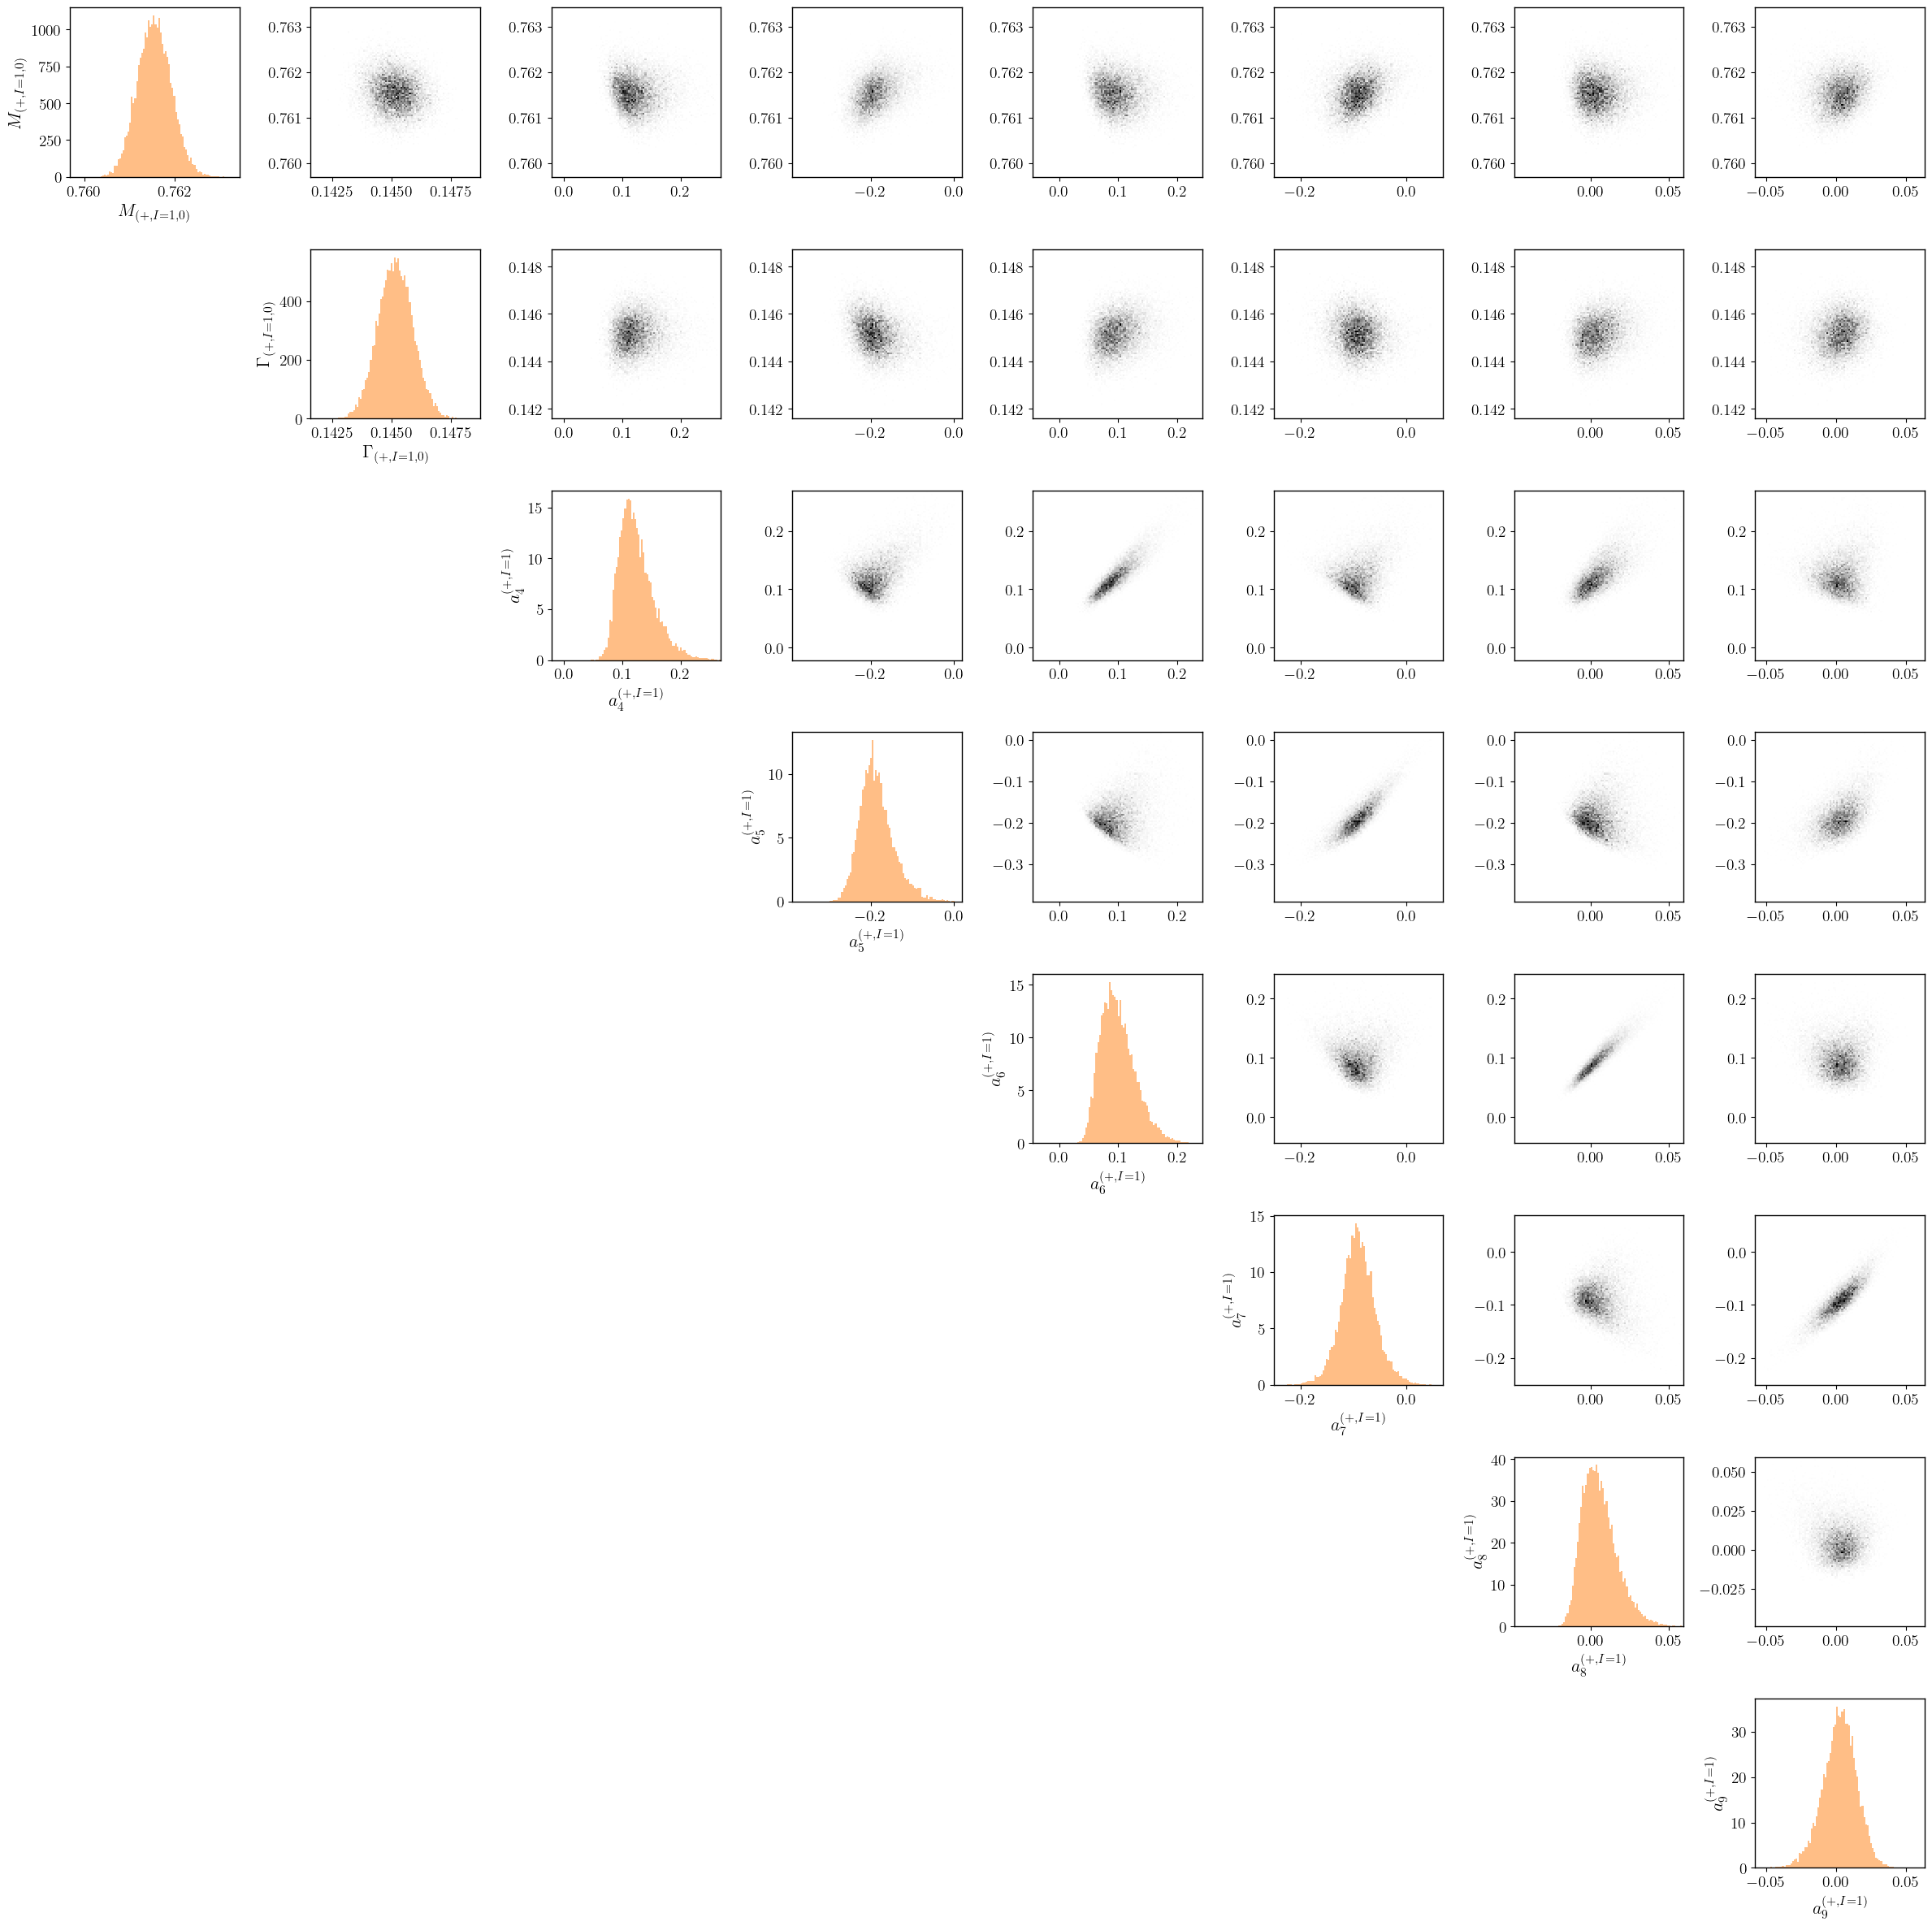

In [213]:
eos.tasks.corner_plot(af, posterior, base_directory=BASE_DIRECTORY)

In [224]:
print(f"rho mass  = {np.average(f.samples[:,0], weights=f.weights):.4f} ± {wstd(f.samples[:,0], weights=f.weights):.4f}")
print(f"rho width = {np.average(f.samples[:,1], weights=f.weights):.4f} ± {wstd(f.samples[:,1], weights=f.weights):.4f}")

rho mass  = 0.7615 ± 0.0004
rho width = 0.1452 ± 0.0007


In [225]:
# Dispersive bound computation
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-dispersive-bound", base_directory=BASE_DIRECTORY)
preds = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-dispersive-bound'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9/pr…

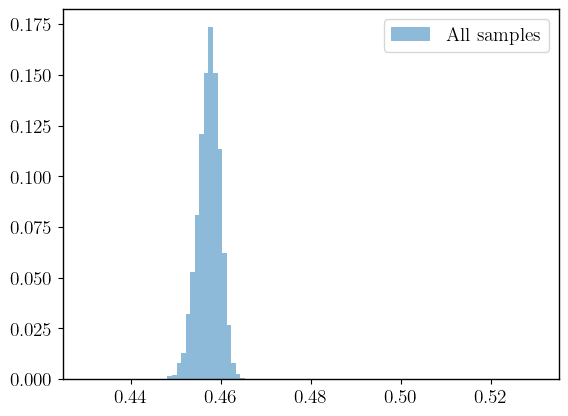

In [226]:
plt.hist(preds.samples, weights=preds.weights, bins=np.linspace(0.43,0.53,100), alpha=0.5, label='All samples')
plt.legend()
plt.show()

In [227]:
disp_values = np.array(preds.samples[:,0])
disp_mean   = np.average(disp_values, weights=preds.weights)
disp_std    = wstd(disp_values, weights=preds.weights)
print(f"Dispersive bound is {disp_mean:.4f} ± {disp_std:.4f}")

Dispersive bound is 0.4573 ± 0.0024


In [228]:
eos.tasks.predict_observables(af, posterior, "FF-fp2-I1-all", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9/pr…

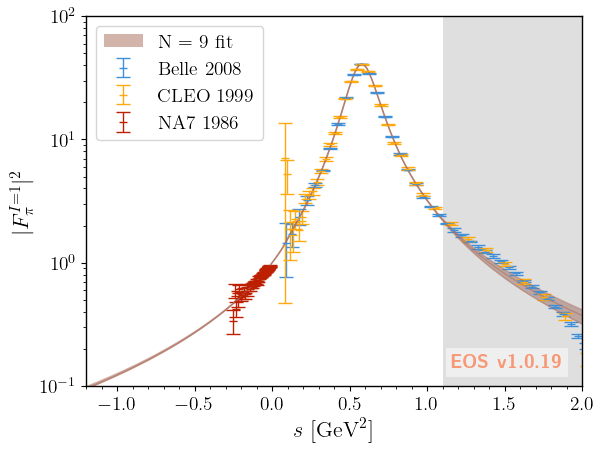

In [229]:
figure_args = {
'watermark': { 'position': 'lower right' },
'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-1.2, 2.0] },
    'yaxis': { 'label': r'$|F^{I=1}_\pi|^2$', 'range': [ 0.1, 100.0], 'scale': 'log' },
    'legend': { 'position': 'upper left' },
    'items': [
    { 'type': 'constraint', 'label': 'Belle 2008', 'color': colors[0],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2)',
        'constraints': '0->pipi::Abs{f_+}^2@Belle:2008C',
    },
    { 'type': 'constraint', 'label': 'CLEO 1999', 'color': colors[1],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2)',
        'constraints': '0->pipi::Abs{f_+}^2@CLEO:2000B',
    },
    { 'type': 'constraint', 'label': 'NA7 1986', 'color': colors[2],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2)',
        'constraints': '0->pipi::Abs{f_+}^2@NA7:1986A',
    },
    { 'type': 'uncertainty', 'label': 'N = 9 fit', 'color': colors[5],
        'variable': 'q2', 'range': [-1.2, 2.0], 'interpolation': 'cubic',
        'datafile': 'data/'+posterior+'/pred-FF-fp2-I1-all', 'resolution': 300
    },
    { 'type': 'band', 'color': 'gray', 'alpha': 0.25, 'x': [1.1, 2.0], 'y': [0.0, 100]}
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [230]:
eos.tasks.predict_observables(af, posterior, "FF-arg-fp-I1-timelike", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9/pr…

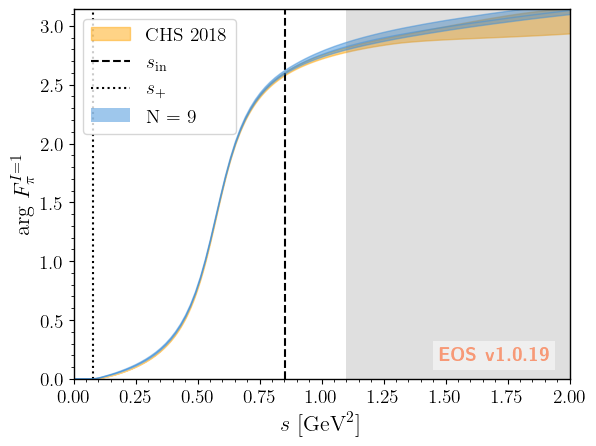

In [231]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [0.0, 2.0] },
    'yaxis': { 'label': r'arg $F^{I=1}_\pi$', 'range': [0.0 , np.pi] },
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'N = 9', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-FF-arg-fp-I1-timelike', 'color': colors[0]
      },
      { 'type': 'band', 'color': 'gray', 'alpha': 0.25, 'x': [1.1, 2.0], 'y': [0.0, np.pi]}
    ]
  }
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)

q2_over_mpisquared, phase, err = np.loadtxt("scripts/d11-central.txt", skiprows=1, unpack=True)
mpi = eos.Parameters()["mass::pi^+"].evaluate()
q2  = q2_over_mpisquared * mpi**2

figure._ax.fill_between(q2, phase-err, phase+err, label="CHS 2018", alpha=0.5, color=colors[1])
figure._ax.plot([sIn, sIn], [0.0, np.pi], color='k', linestyle='--', label= r'$s_\mathrm{in}$')
figure._ax.plot([sPlus, sPlus], [0.0, np.pi], color='k', linestyle=':', label= r'$s_+$')
figure._ax.legend(loc="upper left")

figure.draw()

In [232]:
get_gof(analysis, start_point)
analysis.parameters.dump('data/'+posterior+'/mode-default/parameters.yaml')

Handling item to plot 0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026 in the complex plane
Overriding parameters from file
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,2)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(0,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(0,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,2)@KSvD2025' with central value '0'
[parameters.override] Overriding existing p

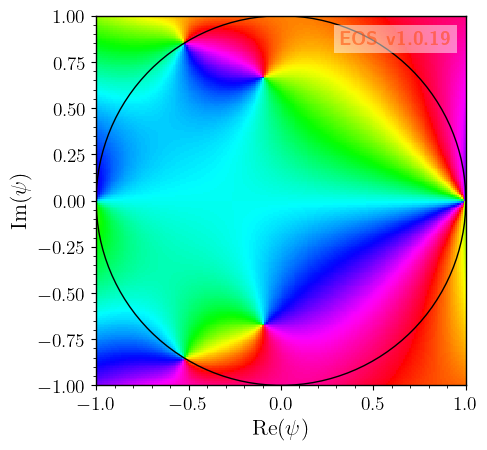

In [233]:
figure_args = {
'plot': {
    'xaxis': { 'label': r'$\mathrm{Re}(\psi)$', 'range': [-1.0, 1.0] },
    'yaxis': { 'label': r'$\mathrm{Im}(\psi)$', 'range': [-1.0, 1.0] },
    # 'legend': { 'position': 'upper left' },
    'items': [
    { 'type': 'complex-plane', 'label': 'N = 9 fit', 'colormap': 'hsv',
        'variables': ["Re{psi}", "Im{psi}"], 'observable': "0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026",
        'fixed_parameters_from_file': 'data/'+posterior+'/mode-default/parameters.yaml', 'resolution': 200
    }
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()
circle = plt.Circle((0, 0), 1.0, color='k', fill=False)
figure._ax.add_patch(circle)
figure._ax.set_aspect("equal", adjustable="box")


In [234]:
eos.tasks.predict_observables(af, posterior, "real-partial-wave-I1", base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables(af, posterior, "imag-partial-wave-I1", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9/pr…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9/pr…

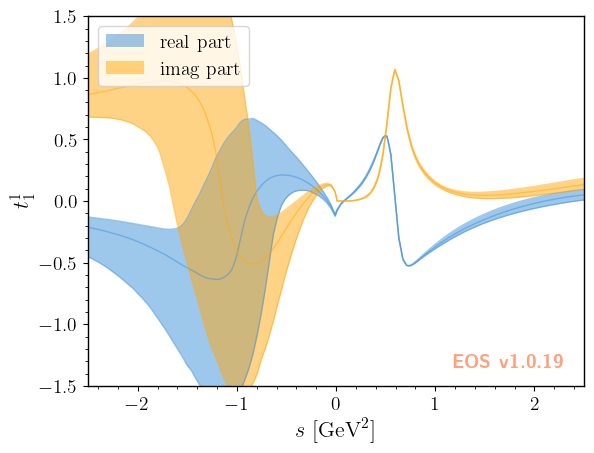

In [237]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-2.5, 2.5] },
    'yaxis': { 'label': '$t_1^1$',  'range': [-1.5, 1.5]},
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'real part', 'interpolation': 'linear', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-real-partial-wave-I1'
      },
      { 'type': 'uncertainty', 'label': 'imag part', 'interpolation': 'linear', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-imag-partial-wave-I1'
      },
    ]
  }
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

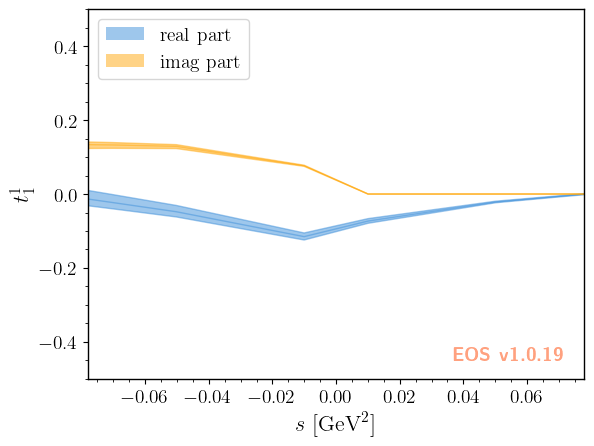

In [238]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-sPlus, sPlus] },
    'yaxis': { 'label': '$t_1^1$',  'range': [-0.5, 0.5]},
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'real part', 'interpolation': 'linear', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-real-partial-wave-I1'
      },
      { 'type': 'uncertainty', 'label': 'imag part', 'interpolation': 'linear', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-imag-partial-wave-I1'
      },
    ]
  }
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [239]:
# Analytic value of a11
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-scattering-length-params", base_directory=BASE_DIRECTORY)
sl_params = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-scattering-length-params'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9/pr…

In [240]:
a11_values = np.array(list(map(a11_calculator, sl_params.samples)))* mpi**2
a11_mean   = np.average(a11_values, weights=sl_params.weights)
a11_std    = wstd(a11_values, weights=sl_params.weights)
print(f"a11 = {a11_mean:.4f} ± {a11_std:.4f}")

a11 = 0.0148 ± 0.0013


In [241]:
# Charge radius
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-pion-charge-radius-param", base_directory=BASE_DIRECTORY)
fprime_values = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-pion-charge-radius-param'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9/pr…

In [242]:
charge_radius_squared_values = np.array(list(map(charge_radius_squared_calculator, fprime_values.samples[:, 0])))
radius_mean  = np.average(charge_radius_squared_values, weights=fprime_values.weights)
radius_std   = wstd(charge_radius_squared_values, weights=fprime_values.weights)

print(f"<r^2> = {radius_mean:.4f} ± {radius_std:.4f} fm^2")

<r^2> = 0.4272 ± 0.0037 fm^2


In [243]:
# Residue at the rho pole
eos.tasks.predict_observables(af, posterior, "re-rho-residue-psi", base_directory=BASE_DIRECTORY)
re_res_psi = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-re-rho-residue-psi'))
eos.tasks.predict_observables(af, posterior, "im-rho-residue-psi", base_directory=BASE_DIRECTORY)
im_res_psi = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-im-rho-residue-psi'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9/pr…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9/pr…

In [244]:
re_res = re_res_psi.samples[:,0]
im_res = im_res_psi.samples[:,0]
M      = f.samples[:,0]
Gamma  = f.samples[:,1]

print(len(re_res), len(im_res), len(M), len(Gamma)) # check that they have the same length

16661 16661 16661 16661


In [245]:
data = []

for r, i, m, g in zip(re_res, im_res, M, Gamma):
    data.append([r, i, m, g])

with open("residues_psi_order9.wl", "w") as file:
    lines = [f"{{{r}, {i}, {m}, {g}}}" for r, i, m, g in data]
    file.write("{\n" + ",\n".join(lines) + "\n}")

In [120]:
with open("residues_s_order9.wl") as file:
    text = file.read()

# Replace Mathematica braces with Python brackets
text = text.replace("{", "[").replace("}", "]")

data = ast.literal_eval(text)

In [121]:
res_s       = np.array([re + 1j * im for re, im in data])
res_s_mean  = np.average(res_s, weights=f.weights)
radius_std  = wstd(res_s, weights=f.weights)
print(f"residue at s_rho is ({np.real(res_s_mean):.4f} ± {np.real(radius_std):.4f}) + i * ({np.imag(res_s_mean):.4f} ± {np.imag(radius_std):.4f})")

residue at s_rho is (-0.7666 ± 0.0135) + i * (0.3188 ± 0.0188)


In [122]:
# Computing g_{rho pi pi} and g_{rho gamma}
f_at_s_rho       = np.array([get_f_rho(s, analysis) for s in f.samples])
f_at_s_rho_value = f_at_s_rho[:,0] + 1j * f_at_s_rho[:,1]

In [123]:
s_rho       = (M - 1j * Gamma / 2)**2
g_rho_gamma = np.sqrt(24j * np.pi * s_rho / f_at_s_rho_value / res_s / (np.sqrt(1 - sPlus / s_rho))**3)
g_rho_pi_pi = - res_s / s_rho * g_rho_gamma

In [124]:
g_rho_gamma_mean = np.average(g_rho_gamma, weights=f.weights)
g_rho_gamma_std  = wstd(g_rho_gamma, weights=f.weights)
print(f"g_rho_gamma =  ({np.real(g_rho_gamma_mean):.4f} ± {np.real(g_rho_gamma_std):.4f}) + i * ({np.imag(g_rho_gamma_mean):.4f} ± {np.imag(g_rho_gamma_std):.4f})")

g_rho_pi_pi_mean = np.average(g_rho_pi_pi, weights=f.weights)
g_rho_pi_pi_std  = wstd(g_rho_pi_pi, weights=f.weights)
print(f"g_rho_pi_pi =  ({np.real(g_rho_pi_pi_mean):.4f} ± {np.real(g_rho_pi_pi_std):.4f}) + i * ({np.imag(g_rho_pi_pi_mean):.4f} ± {np.imag(g_rho_pi_pi_std):.4f})")

g_rho_gamma =  (4.5278 ± 0.0024) + i * (0.2066 ± -0.0096)
g_rho_pi_pi =  (6.3753 ± 0.0710) + i * (-1.0189 ± 0.1670)


## 0 -> pi pi order 10

In [24]:
posterior = 'FF-fp-I1-order10'
analysis  = af.analysis(posterior)

Creating analysis with 9 priors, 3 EOS-wide constraints, 2 global options, 2 manually-entered constraints and 2 fixed parameters.
likelihood probably depends on 8 parameter(s) that do not appear in the prior; check prior?


In [30]:
start_point = [0.76111103,  0.14523666,  0.06647979, -0.26817412,  0.11713944,
       -0.13300641,  0.09049566, -0.00911386,  0.042892]

In [31]:
get_gof(analysis, start_point)

In [33]:
bfp, gof = eos.tasks.find_mode(af, posterior, start_point=start_point, base_directory=BASE_DIRECTORY, optimizations=100)
#bfp, gof = eos.tasks.find_mode(af, posterior, importance_samples=True, base_directory=BASE_DIRECTORY, optimizations=100)
display(gof)
bfp.point

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order10/m…

array([ 0.7611107 ,  0.14523721,  0.06648195, -0.26818255,  0.11713781,
       -0.13299599,  0.09049098, -0.00910465,  0.04289165])

In [34]:
if resample:
    eos.tasks.sample_nested(af, posterior, base_directory=BASE_DIRECTORY, bound='multi', nlive=250)

f = eos.data.ImportanceSamples(os.path.join(BASE_DIRECTORY, 'data', posterior, 'samples'))
print(f"Collected {f.samples.shape[0]} samples")

Collected 16495 samples


In [35]:
for i, p in enumerate(analysis.varied_parameters):
    mean = np.average(f.samples[:,i], weights=f.weights)
    std  = wstd(f.samples[:,i], weights=f.weights)
    print(f"      - {{ 'parameter': '{p.name()}', 'min':  {mean - 5*std:.5f}, 'max':  {mean + 5*std:.5f}, 'type': 'uniform'}}")

      - { 'parameter': '0->pipi::M_(+,1,0)@BHKMNR2026', 'min':  0.75911, 'max':  0.76342, 'type': 'uniform'}
      - { 'parameter': '0->pipi::Gamma_(+,1,0)@BHKMNR2026', 'min':  0.14188, 'max':  0.14891, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^4@BHKMNR2026', 'min':  -0.07371, 'max':  0.30060, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^5@BHKMNR2026', 'min':  -0.53063, 'max':  0.05477, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^6@BHKMNR2026', 'min':  -0.08806, 'max':  0.44395, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^7@BHKMNR2026', 'min':  -0.37601, 'max':  0.12246, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^8@BHKMNR2026', 'min':  -0.16407, 'max':  0.41659, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^9@BHKMNR2026', 'min':  -0.10936, 'max':  0.08710, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^10@BHKMNR2026', 'min':  -0.06078, 'max':  0.16118, 'type': 'uniform'}


Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order10/p…

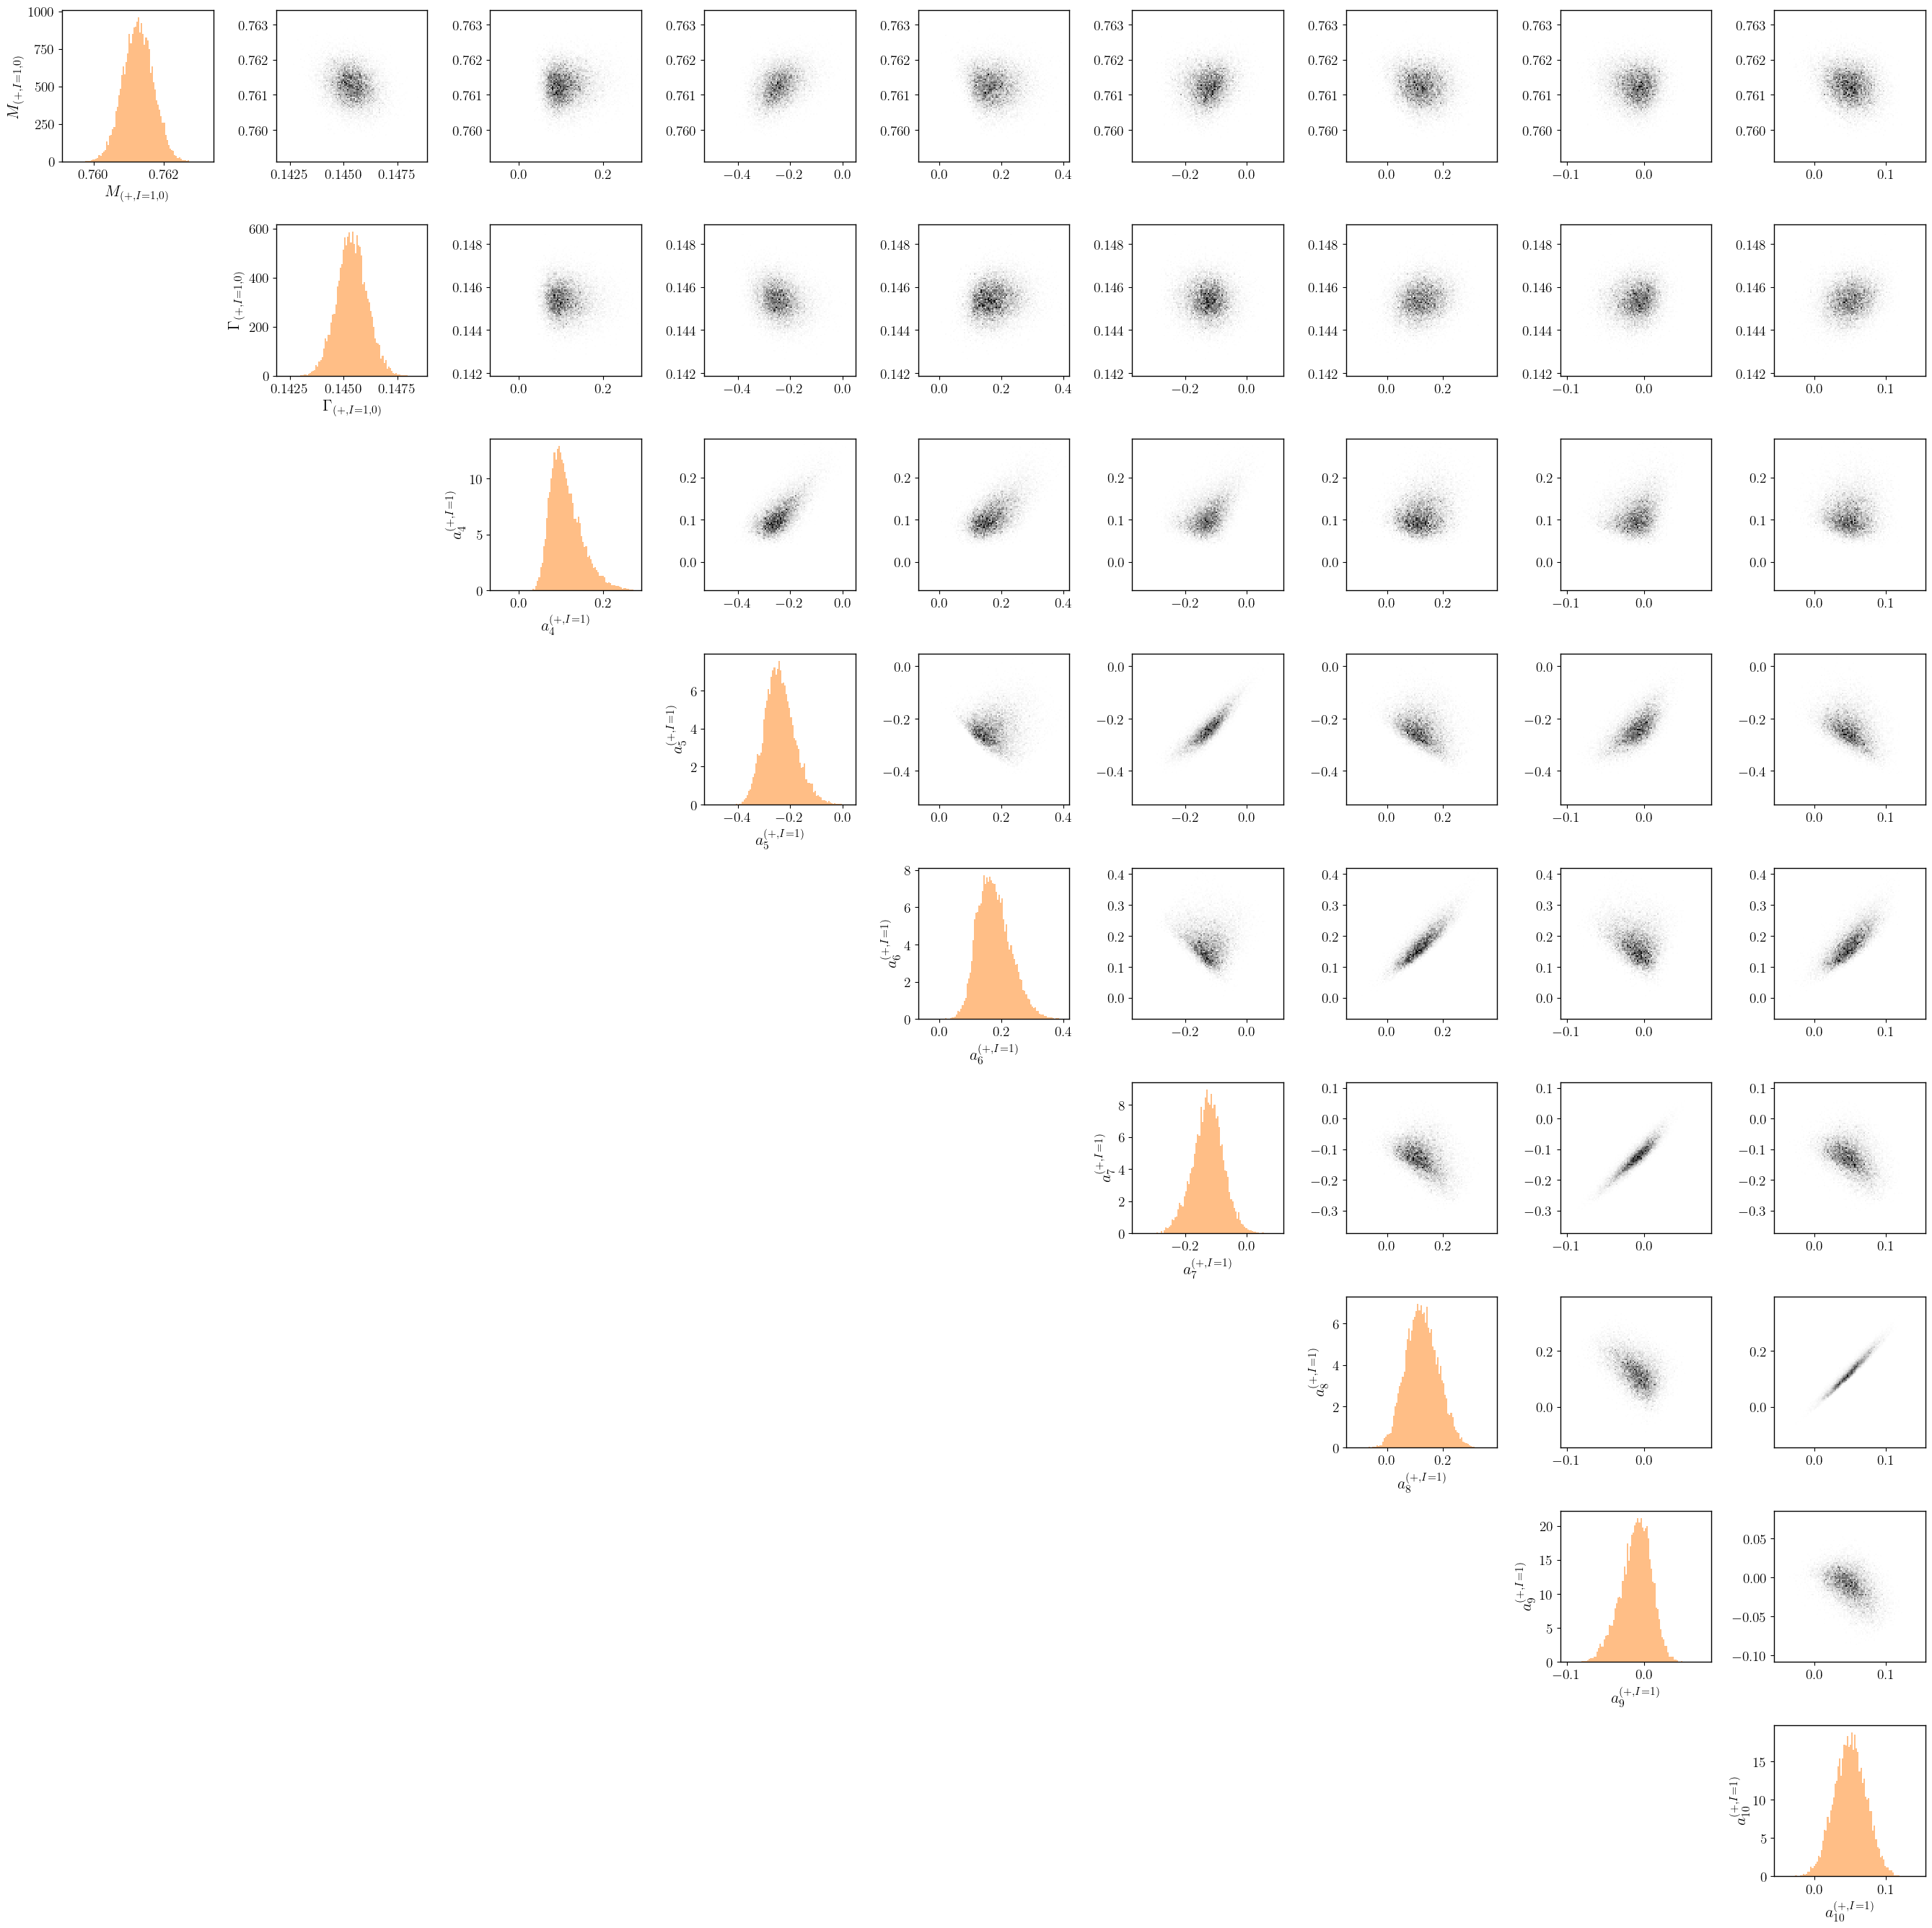

In [36]:
eos.tasks.corner_plot(af, posterior, base_directory=BASE_DIRECTORY)

In [37]:
print(f"rho mass  = {np.average(f.samples[:,0], weights=f.weights):.4f} ± {wstd(f.samples[:,0], weights=f.weights):.4f}")
print(f"rho width = {np.average(f.samples[:,1], weights=f.weights):.4f} ± {wstd(f.samples[:,1], weights=f.weights):.4f}")

rho mass  = 0.7613 ± 0.0004
rho width = 0.1454 ± 0.0007


In [38]:
# Dispersive bound computation
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-dispersive-bound", base_directory=BASE_DIRECTORY)
preds = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-dispersive-bound'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order10/p…

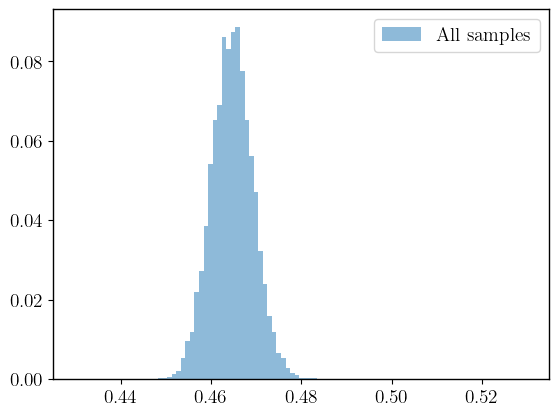

In [39]:
plt.hist(preds.samples, weights=preds.weights, bins=np.linspace(0.43,0.53,100), alpha=0.5, label='All samples')
plt.legend()
plt.show()

In [40]:
disp_values = np.array(preds.samples[:,0])
disp_mean   = np.average(disp_values, weights=preds.weights)
disp_std    = wstd(disp_values, weights=preds.weights)
print(f"Dispersive bound is {disp_mean:.4f} ± {disp_std:.4f}")

Dispersive bound is 0.4646 ± 0.0046


In [41]:
eos.tasks.predict_observables(af, posterior, "FF-fp2-I1-all", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order10/p…

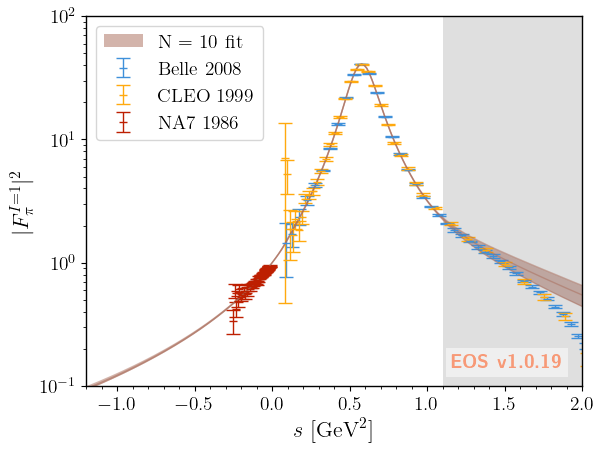

In [42]:
figure_args = {
'watermark': { 'position': 'lower right' },
'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-1.2, 2.0] },
    'yaxis': { 'label': r'$|F^{I=1}_\pi|^2$', 'range': [ 0.1, 100.0], 'scale': 'log' },
    'legend': { 'position': 'upper left' },
    'items': [
    { 'type': 'constraint', 'label': 'Belle 2008', 'color': colors[0],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2)',
        'constraints': '0->pipi::Abs{f_+}^2@Belle:2008C',
    },
    { 'type': 'constraint', 'label': 'CLEO 1999', 'color': colors[1],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2)',
        'constraints': '0->pipi::Abs{f_+}^2@CLEO:2000B',
    },
    { 'type': 'constraint', 'label': 'NA7 1986', 'color': colors[2],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2)',
        'constraints': '0->pipi::Abs{f_+}^2@NA7:1986A',
    },
    { 'type': 'uncertainty', 'label': 'N = 10 fit', 'color': colors[5],
        'variable': 'q2', 'range': [-1.2, 2.0], 'interpolation': 'cubic',
        'datafile': 'data/'+posterior+'/pred-FF-fp2-I1-all', 'resolution': 300
    },
    { 'type': 'band', 'color': 'gray', 'alpha': 0.25, 'x': [1.1, 2.0], 'y': [0.0, 100]}
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [43]:
eos.tasks.predict_observables(af, posterior, "FF-arg-fp-I1-timelike", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order10/p…

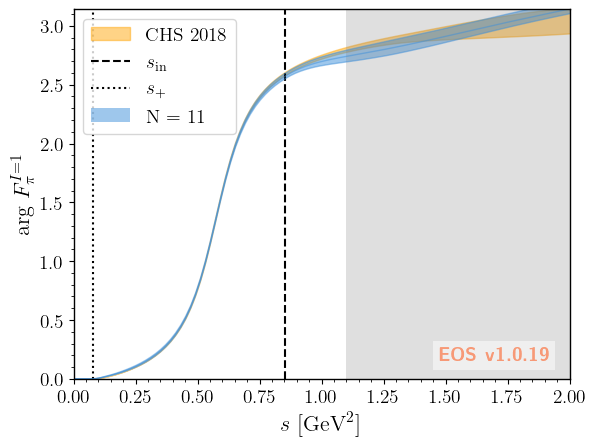

In [44]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [0.0, 2.0] },
    'yaxis': { 'label': r'arg $F^{I=1}_\pi$', 'range': [0.0 , np.pi] },
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'N = 11', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-FF-arg-fp-I1-timelike', 'color': colors[0]
      },
      { 'type': 'band', 'color': 'gray', 'alpha': 0.25, 'x': [1.1, 2.0], 'y': [0.0, np.pi]}
    ]
  }
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)

q2_over_mpisquared, phase, err = np.loadtxt("scripts/d11-central.txt", skiprows=1, unpack=True)
mpi = eos.Parameters()["mass::pi^+"].evaluate()
q2  = q2_over_mpisquared * mpi**2

figure._ax.fill_between(q2, phase-err, phase+err, label="CHS 2018", alpha=0.5, color=colors[1])
figure._ax.plot([sIn, sIn], [0.0, np.pi], color='k', linestyle='--', label= r'$s_\mathrm{in}$')
figure._ax.plot([sPlus, sPlus], [0.0, np.pi], color='k', linestyle=':', label= r'$s_+$')
figure._ax.legend(loc="upper left")

figure.draw()

In [45]:
get_gof(analysis, start_point)
analysis.parameters.dump('data/'+posterior+'/mode-default/parameters.yaml')

Handling item to plot 0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026 in the complex plane
Overriding parameters from file
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,2)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(0,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(0,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,2)@KSvD2025' with central value '0'
[parameters.override] Overriding existing p

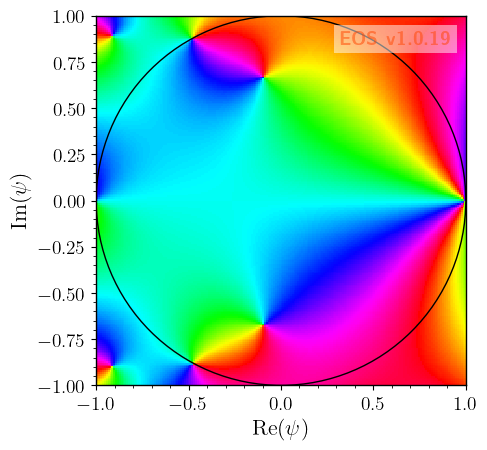

In [48]:
figure_args = {
'plot': {
    'xaxis': { 'label': r'$\mathrm{Re}(\psi)$', 'range': [-1.0, 1.0] },
    'yaxis': { 'label': r'$\mathrm{Im}(\psi)$', 'range': [-1.0, 1.0] },
    # 'legend': { 'position': 'upper left' },
    'items': [
    { 'type': 'complex-plane', 'label': 'N = 10 fit', 'colormap': 'hsv',
        'variables': ["Re{psi}", "Im{psi}"], 'observable': "0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026",
        'fixed_parameters_from_file': 'data/'+posterior+'/mode-default/parameters.yaml', 'resolution': 200
    }
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()
circle = plt.Circle((0, 0), 1.0, color='k', fill=False)
figure._ax.add_patch(circle)
figure._ax.set_aspect("equal", adjustable="box")

In [49]:
eos.tasks.predict_observables(af, posterior, "real-partial-wave-I1", base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables(af, posterior, "imag-partial-wave-I1", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order10/p…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order10/p…

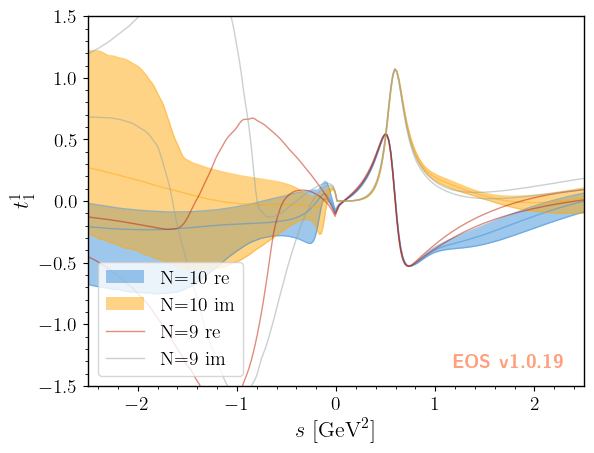

In [50]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-2.5, 2.5] },
    'yaxis': { 'label': '$t_1^1$',  'range': [-1.5, 1.5]},
    'legend': { 'position': 'lower left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'N=10 re', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-real-partial-wave-I1'
      },
      { 'type': 'uncertainty', 'label': 'N=10 im', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-imag-partial-wave-I1'
      },
      { 'type': 'uncertainty', 'label': 'N=9 re', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/FF-fp-I1-order9/pred-real-partial-wave-I1', 'band': 'outer'
      },
      { 'type': 'uncertainty', 'label': 'N=9 im', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/FF-fp-I1-order9/pred-imag-partial-wave-I1', 'band': 'outer'
      },
    ]
  }
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

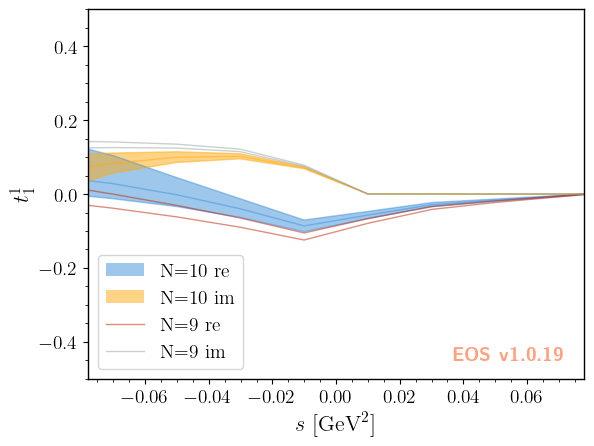

In [51]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-sPlus, sPlus] },
    'yaxis': { 'label': '$t_1^1$',  'range': [-0.5, 0.5]},
    'legend': { 'position': 'lower left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'N=10 re', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-real-partial-wave-I1'
      },
      { 'type': 'uncertainty', 'label': 'N=10 im', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-imag-partial-wave-I1'
      },
      { 'type': 'uncertainty', 'label': 'N=9 re', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/FF-fp-I1-order9/pred-real-partial-wave-I1', 'band': 'outer'
      },
      { 'type': 'uncertainty', 'label': 'N=9 im', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/FF-fp-I1-order9/pred-imag-partial-wave-I1', 'band': 'outer'
      },
    ]
  }
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [52]:
# Analytic value of a11
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-scattering-length-params", base_directory=BASE_DIRECTORY)
sl_params = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-scattering-length-params'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order10/p…

In [53]:
a11_values = np.array(list(map(a11_calculator, sl_params.samples)))* mpi**2
a11_mean   = np.average(a11_values, weights=sl_params.weights)
a11_std    = wstd(a11_values, weights=sl_params.weights)
print(f"a11 = {a11_mean:.4f} ± {a11_std:.4f}")

a11 = 0.0124 ± 0.0017


In [54]:
# Charge radius
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-pion-charge-radius-param", base_directory=BASE_DIRECTORY)
fprime_values = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-pion-charge-radius-param'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order10/p…

In [55]:
charge_radius_squared_values = np.array(list(map(charge_radius_squared_calculator, fprime_values.samples[:, 0])))
radius_mean = np.average(charge_radius_squared_values, weights=fprime_values.weights)
radius_std  = wstd(charge_radius_squared_values, weights=fprime_values.weights)
print(f"<r^2> = {radius_mean:.4f} ± {radius_std:.4f} fm^2")

<r^2> = 0.4241 ± 0.0038 fm^2


In [56]:
# Residue at the rho pole
eos.tasks.predict_observables(af, posterior, "re-rho-residue-psi", base_directory=BASE_DIRECTORY)
re_res_psi = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-re-rho-residue-psi'))
eos.tasks.predict_observables(af, posterior, "im-rho-residue-psi", base_directory=BASE_DIRECTORY)
im_res_psi = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-im-rho-residue-psi'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order10/p…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order10/p…

In [57]:
re_res = re_res_psi.samples[:,0]
im_res = im_res_psi.samples[:,0]
M      = f.samples[:,0]
Gamma  = f.samples[:,1]

print(len(re_res), len(im_res), len(M), len(Gamma)) # check that they have the same length

16495 16495 16495 16495


In [58]:
data = []

for r, i, m, g in zip(re_res, im_res, M, Gamma):
    data.append([r, i, m, g])

with open("residues_psi_order10.wl", "w") as file:
    lines = [f"{{{r}, {i}, {m}, {g}}}" for r, i, m, g in data]
    file.write("{\n" + ",\n".join(lines) + "\n}")

In [40]:
with open("residues_s_order10.wl") as file:
    text = file.read()

# Replace Mathematica braces with Python brackets
text = text.replace("{", "[").replace("}", "]")

data = ast.literal_eval(text)

FileNotFoundError: [Errno 2] No such file or directory: 'residues_s_order10.wl'

In [43]:
res_s       = np.array([re + 1j * im for re, im in data])
res_s_mean  = np.average(res_s, weights=f.weights)
radius_std  = wstd(res_s, weights=f.weights)
print(f"residue at s_rho is ({np.real(res_s_mean):.4f} ± {np.real(radius_std):.4f}) + i * ({np.imag(res_s_mean):.4f} ± {np.imag(radius_std):.4f})")

residue at s_rho is (-0.7360 ± 0.0217) + i * (0.1290 ± 0.0311)


In [46]:
# Computing g_{rho pi pi} and g_{rho gamma}
f_at_s_rho       = np.array([get_f_rho(s, analysis) for s in f.samples])
f_at_s_rho_value = f_at_s_rho[:,0] + 1j * f_at_s_rho[:,1]

In [47]:
s_rho       = (M - 1j * Gamma / 2)**2
g_rho_gamma = np.sqrt(24j * np.pi * s_rho / f_at_s_rho_value / res_s / (np.sqrt(1 - sPlus / s_rho))**3)
g_rho_pi_pi = - res_s / s_rho * g_rho_gamma

In [ ]:
g_rho_gamma_mean = np.average(g_rho_gamma, weights=f.weights)
g_rho_gamma_std  = wstd(g_rho_gamma, weights=f.weights)
print(f"g_rho_gamma = ({np.real(g_rho_gamma_mean):.4f} ± {np.real(g_rho_gamma_std):.4f}) + i * ({np.imag(g_rho_gamma_mean):.4f} ± {np.imag(g_rho_gamma_std):.4f})")

g_rho_pi_pi_mean = np.average(g_rho_pi_pi, weights=f.weights)
g_rho_pi_pi_std  = wstd(g_rho_pi_pi, weights=f.weights)
print(f"g_rho_pi_pi = ({np.real(g_rho_pi_pi_mean):.4f} ± {np.real(g_rho_pi_pi_std):.4f}) + i * ({np.imag(g_rho_pi_pi_mean):.4f} ± {np.imag(g_rho_pi_pi_std):.4f})")


g_rho_gamma = (4.8528 ± 0.0150) + i * (-0.1743 ± -0.0045)
g_rho_pi_pi = (6.2224 ± 0.1286) + i * (-0.1042 ± 0.2898)


## 0 -> pi pi order 11

In [150]:
posterior = 'FF-fp-I1-order11'
analysis  = af.analysis(posterior)

Creating analysis with 10 priors, 3 EOS-wide constraints, 2 global options, 2 manually-entered constraints and 2 fixed parameters.
likelihood probably depends on 7 parameter(s) that do not appear in the prior; check prior?


In [86]:
start_point = [0.76086022,  0.14455674, -0.04429375, -0.26459458,  0.01308645,
        0.03316262,  0.03985136,  0.17928961,  0.02844747,  0.0672916]

In [87]:
get_gof(analysis, start_point)

In [65]:
bfp, gof = eos.tasks.find_mode(af, posterior, start_point=start_point, base_directory=BASE_DIRECTORY, optimizations=100)
#bfp, gof = eos.tasks.find_mode(af, posterior, importance_samples=True, base_directory=BASE_DIRECTORY, optimizations=100)
display(gof)
bfp.point

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order11/m…

array([ 0.7608591 ,  0.14455621, -0.04436696, -0.26474935,  0.01313409,
        0.03297027,  0.04004147,  0.17913093,  0.02855181,  0.06724419])

In [151]:
if resample:
    eos.tasks.sample_nested(af, posterior, base_directory=BASE_DIRECTORY, bound='multi', nlive=200)

f = eos.data.ImportanceSamples(os.path.join(BASE_DIRECTORY, 'data', posterior, 'samples'))
print(f"Collected {f.samples.shape[0]} samples")

Collected 15149 samples


In [61]:
for i, p in enumerate(analysis.varied_parameters):
    mean = np.average(f.samples[:,i], weights=f.weights)
    std  = wstd(f.samples[:,i], weights=f.weights)
    print(f"      - {{ 'parameter': '{p.name()}', 'min':  {mean - 5*std:.5f}, 'max':  {mean + 5*std:.5f}, 'type': 'uniform'}}")

      - { 'parameter': '0->pipi::M_(+,1,0)@BHKMNR2026', 'min':  0.75904, 'max':  0.76329, 'type': 'uniform'}
      - { 'parameter': '0->pipi::Gamma_(+,1,0)@BHKMNR2026', 'min':  0.14112, 'max':  0.14865, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^4@BHKMNR2026', 'min':  -0.19323, 'max':  0.25212, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^5@BHKMNR2026', 'min':  -0.52997, 'max':  0.02221, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^6@BHKMNR2026', 'min':  -0.17338, 'max':  0.38301, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^7@BHKMNR2026', 'min':  -0.31971, 'max':  0.25850, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^8@BHKMNR2026', 'min':  -0.16619, 'max':  0.34797, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^9@BHKMNR2026', 'min':  -0.12102, 'max':  0.35136, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^10@BHKMNR2026', 'min':  -0.06079, 'max':  0.13736, 'type': 'uniform'}
      -

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order11/p…

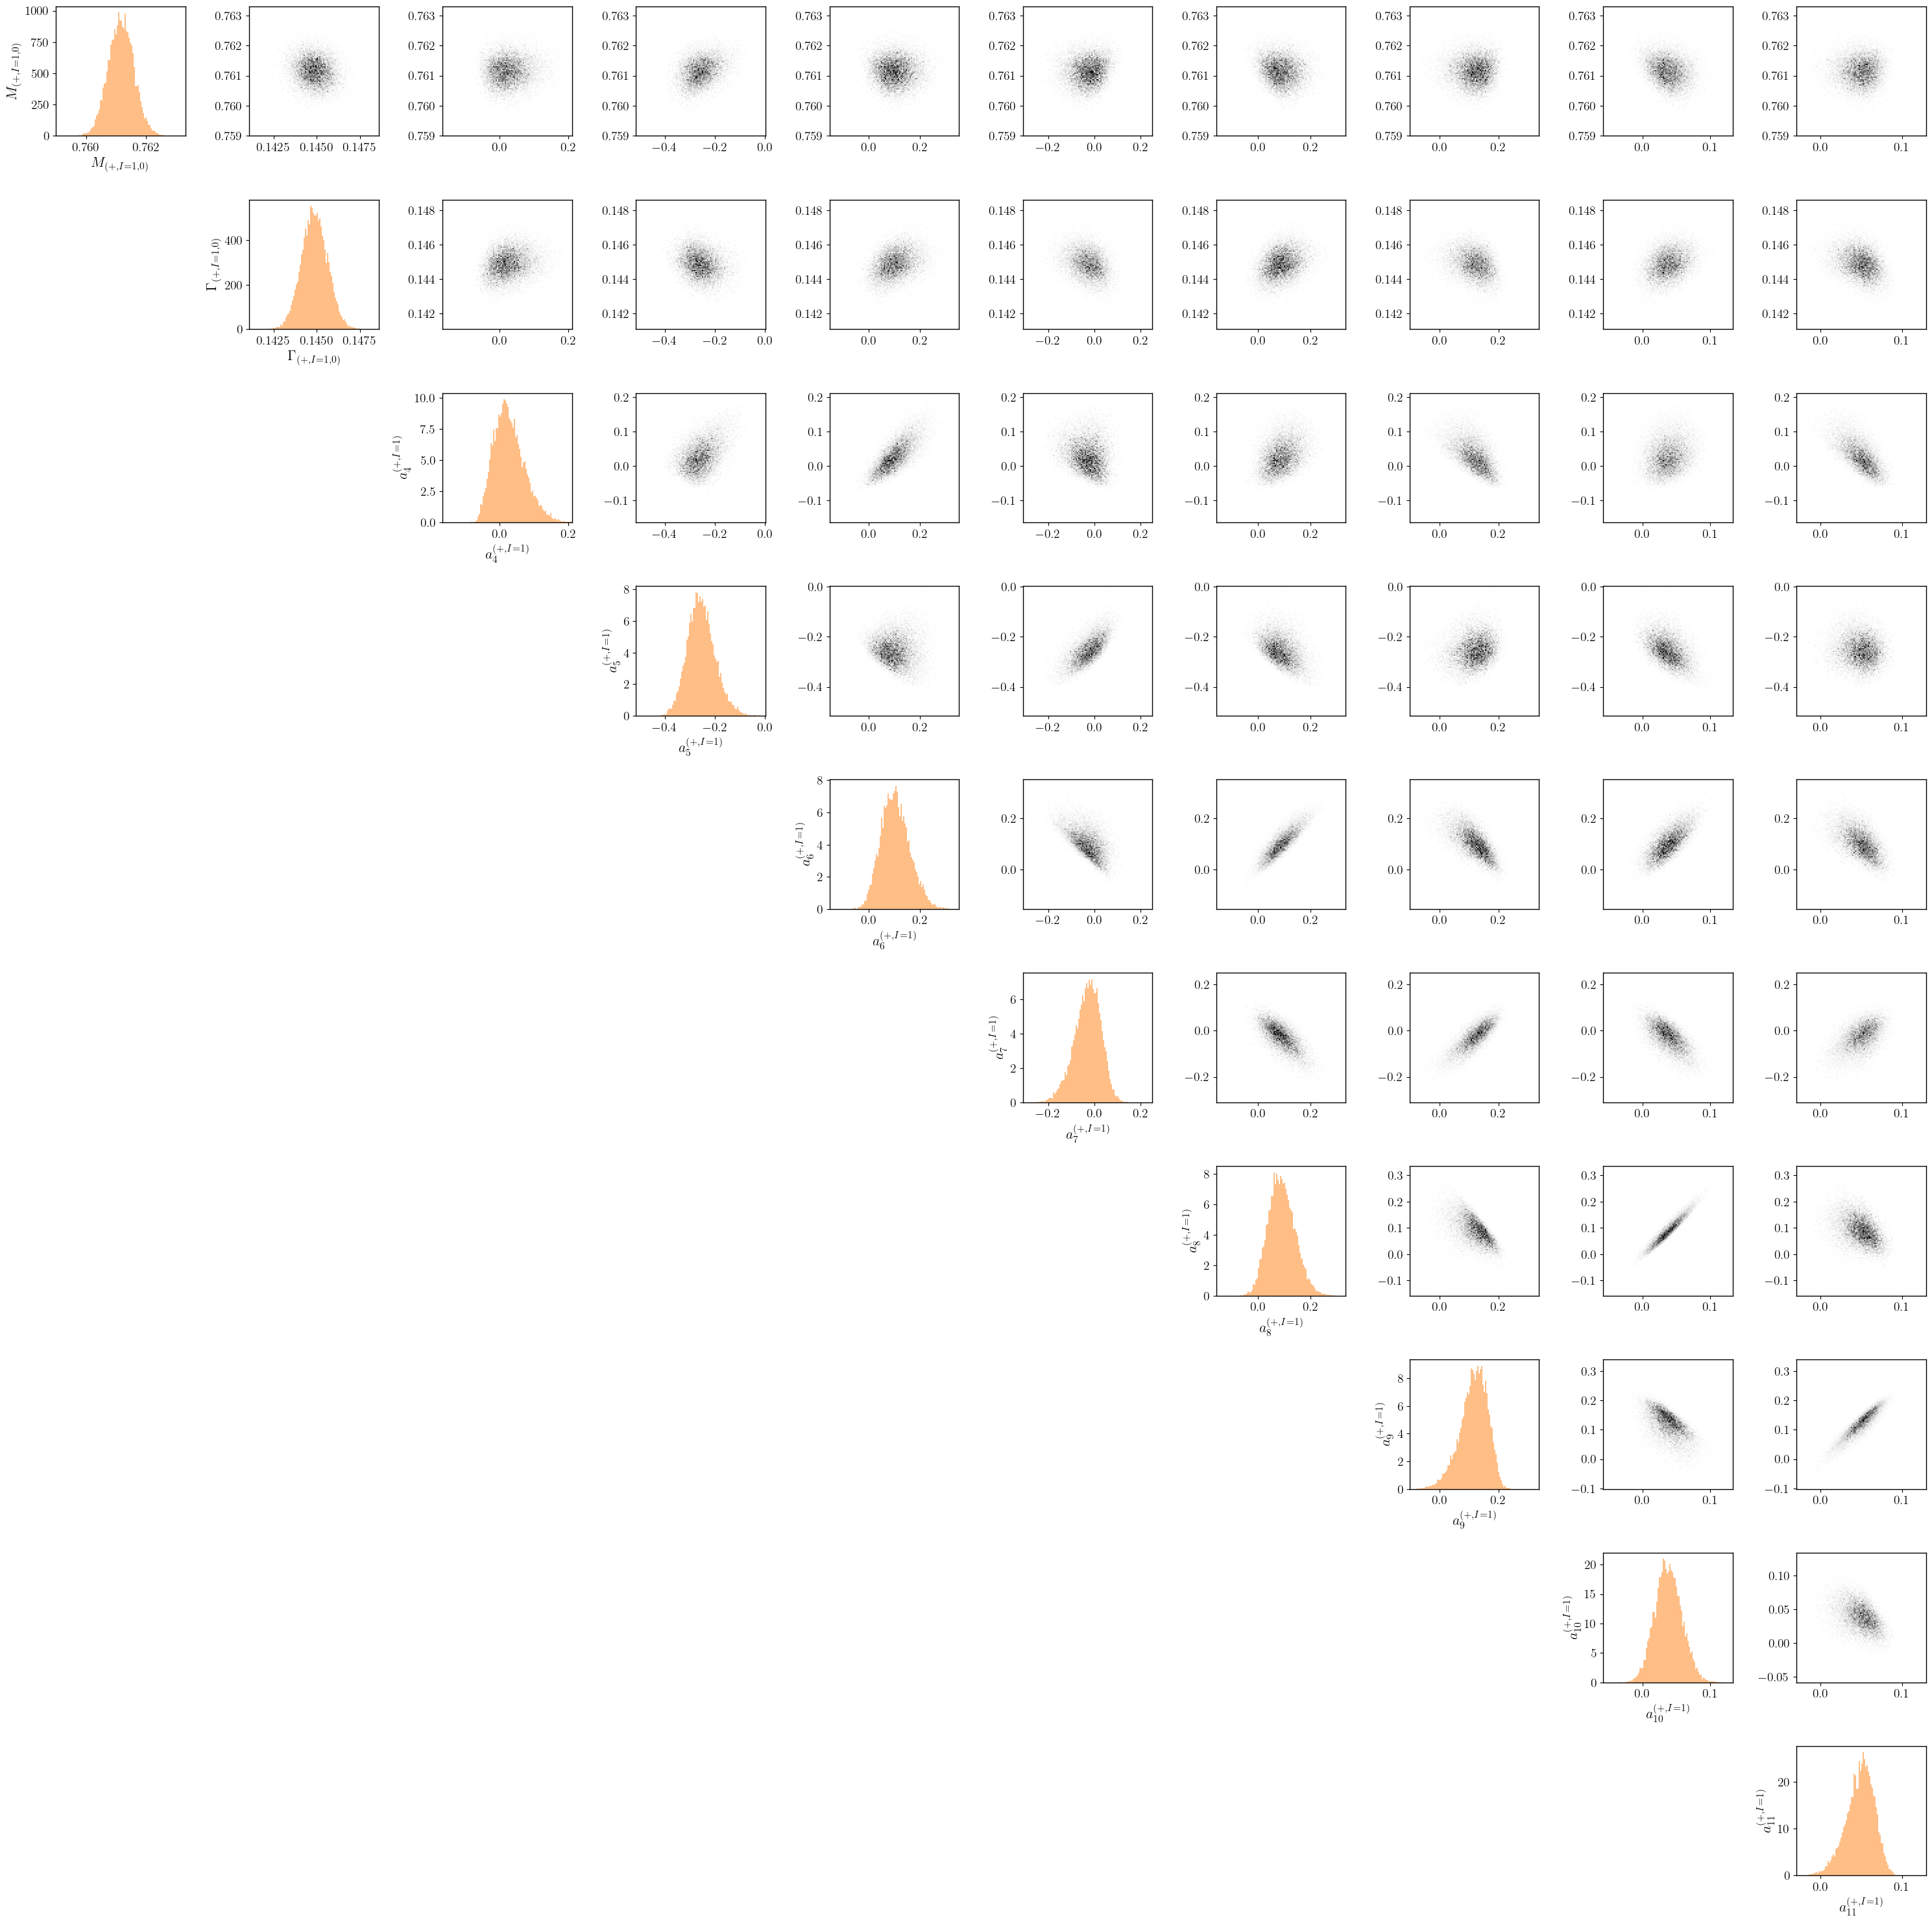

In [62]:
eos.tasks.corner_plot(af, posterior, base_directory=BASE_DIRECTORY)

In [89]:
print(f"rho mass  = {np.average(f.samples[:,0], weights=f.weights):.4f} ± {wstd(f.samples[:,0], weights=f.weights):.4f}")
print(f"rho width = {np.average(f.samples[:,1], weights=f.weights):.4f} ± {wstd(f.samples[:,1], weights=f.weights):.4f}")

rho mass  = 0.7612 ± 0.0004
rho width = 0.1449 ± 0.0008


In [90]:
# Dispersive bound computation
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-dispersive-bound", base_directory=BASE_DIRECTORY)
preds = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-dispersive-bound'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order11/p…

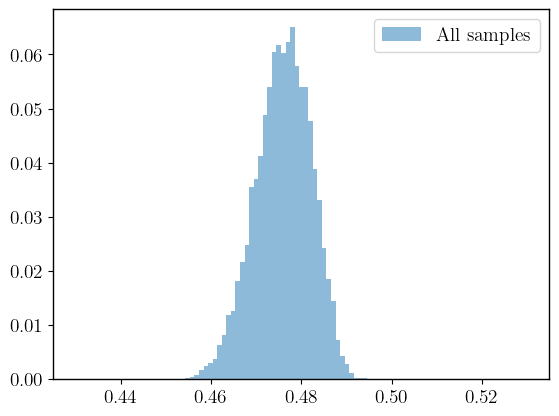

In [91]:
plt.hist(preds.samples, weights=preds.weights, bins=np.linspace(0.43,0.53,100), alpha=0.5, label='All samples')
plt.legend()
plt.show()

In [92]:
disp_values = np.array(preds.samples[:,0])
disp_mean   = np.average(disp_values, weights=preds.weights)
disp_std    = wstd(disp_values, weights=preds.weights)
print(f"Dispersive bound is {disp_mean:.4f} ± {disp_std:.4f}")

Dispersive bound is 0.4759 ± 0.0061


In [93]:
eos.tasks.predict_observables(af, posterior, "FF-fp2-I1-all", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order11/p…

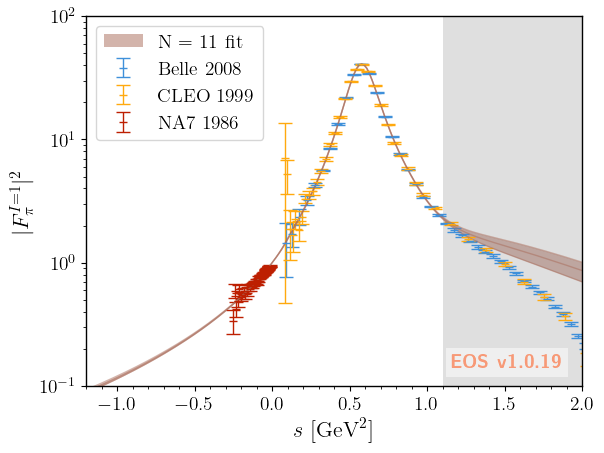

In [94]:
figure_args = {
'watermark': { 'position': 'lower right' },
'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-1.2, 2.0] },
    'yaxis': { 'label': r'$|F^{I=1}_\pi|^2$', 'range': [ 0.1, 100.0], 'scale': 'log' },
    'legend': { 'position': 'upper left' },
    'items': [
    { 'type': 'constraint', 'label': 'Belle 2008', 'color': colors[0],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2)',
        'constraints': '0->pipi::Abs{f_+}^2@Belle:2008C',
    },
    { 'type': 'constraint', 'label': 'CLEO 1999', 'color': colors[1],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2)',
        'constraints': '0->pipi::Abs{f_+}^2@CLEO:2000B',
    },
    { 'type': 'constraint', 'label': 'NA7 1986', 'color': colors[2],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2)',
        'constraints': '0->pipi::Abs{f_+}^2@NA7:1986A',
    },
    { 'type': 'uncertainty', 'label': 'N = 11 fit', 'color': colors[5],
        'variable': 'q2', 'range': [-1.2, 2.0], 'interpolation': 'cubic',
        'datafile': 'data/'+posterior+'/pred-FF-fp2-I1-all', 'resolution': 300
    },
    { 'type': 'band', 'color': 'gray', 'alpha': 0.25, 'x': [1.1, 2.0], 'y': [0.0, 100]}
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [95]:
eos.tasks.predict_observables(af, posterior, "FF-arg-fp-I1-timelike", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order11/p…

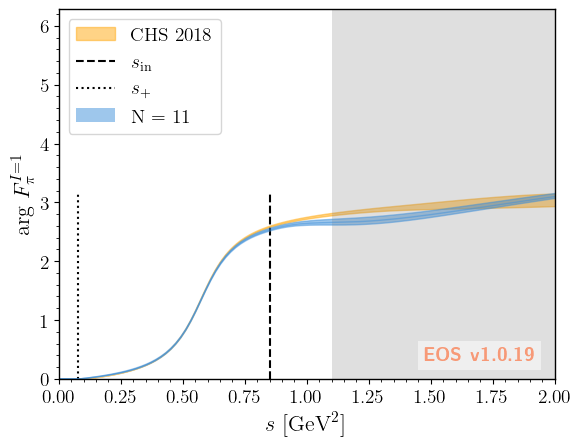

In [96]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [0.0, 2.0] },
    'yaxis': { 'label': r'arg $F^{I=1}_\pi$', 'range': [0.0 , 2*np.pi] },
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'N = 11', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-FF-arg-fp-I1-timelike', 'color': colors[0]
      },
      { 'type': 'band', 'color': 'gray', 'alpha': 0.25, 'x': [1.1, 2.0], 'y': [0.0, 2*np.pi]}
    ]
  }
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)

q2_over_mpisquared, phase, err = np.loadtxt("scripts/d11-central.txt", skiprows=1, unpack=True)
mpi = eos.Parameters()["mass::pi^+"].evaluate()
q2  = q2_over_mpisquared * mpi**2

figure._ax.fill_between(q2, phase-err, phase+err, label="CHS 2018", alpha=0.5, color=colors[1])
figure._ax.plot([sIn, sIn], [0.0, np.pi], color='k', linestyle='--', label= r'$s_\mathrm{in}$')
figure._ax.plot([sPlus, sPlus], [0.0, np.pi], color='k', linestyle=':', label= r'$s_+$')
figure._ax.legend(loc="upper left")

figure.draw()

In [97]:
get_gof(analysis, start_point)
analysis.parameters.dump('data/'+posterior+'/mode-default/parameters.yaml')

Handling item to plot 0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026 in the complex plane
Overriding parameters from file
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,2)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(0,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(0,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,2)@KSvD2025' with central value '0'
[parameters.override] Overriding existing p

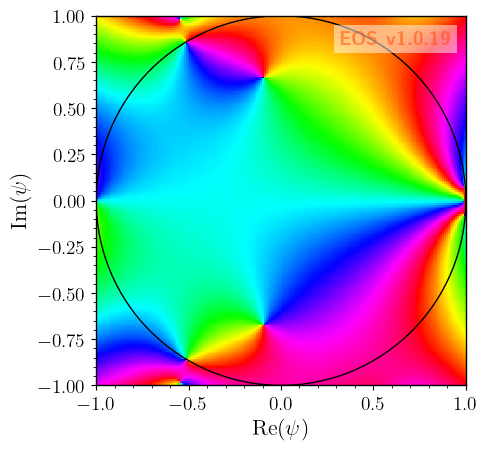

In [100]:
figure_args = {
'plot': {
    'xaxis': { 'label': r'$\mathrm{Re}(\psi)$', 'range': [-1.0, 1.0] },
    'yaxis': { 'label': r'$\mathrm{Im}(\psi)$', 'range': [-1.0, 1.0] },
    # 'legend': { 'position': 'upper left' },
    'items': [
    { 'type': 'complex-plane', 'label': 'N = 11 fit', 'colormap': 'hsv',
        'variables': ["Re{psi}", "Im{psi}"], 'observable': "0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026",
        'fixed_parameters_from_file': 'data/'+posterior+'/mode-default/parameters.yaml', 'resolution': 200
    }
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()
circle = plt.Circle((0, 0), 1.0, color='k', fill=False)
figure._ax.add_patch(circle)
figure._ax.set_aspect("equal", adjustable="box")

In [101]:
eos.tasks.predict_observables(af, posterior, "real-partial-wave-I1", base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables(af, posterior, "imag-partial-wave-I1", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order11/p…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order11/p…

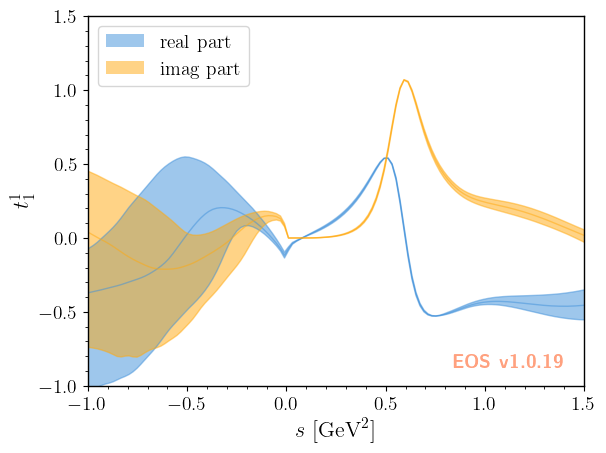

In [102]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-1.0, 1.5] },
    'yaxis': { 'label': '$t_1^1$',  'range': [-1.0, 1.5]},
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'real part', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-real-partial-wave-I1'
      },
      { 'type': 'uncertainty', 'label': 'imag part', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-imag-partial-wave-I1'
      },
    ]
  }
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

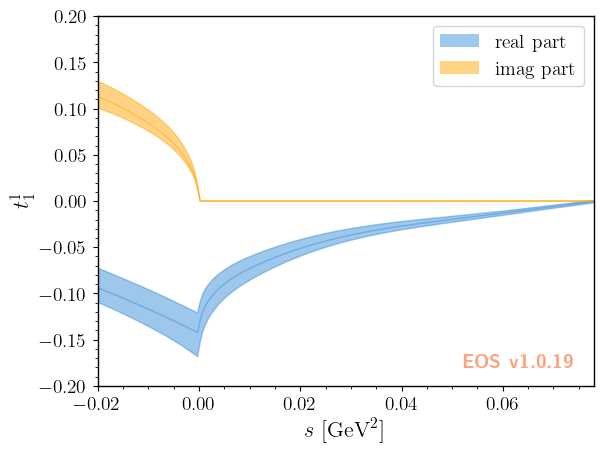

In [156]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-0.02, sPlus] },
    'yaxis': { 'label': '$t_1^1$',  'range': [-0.2, 0.2]},
    'legend': { 'position': 'upper right' },
    'items': [
      { 'type': 'uncertainty', 'label': 'real part', 'interpolation': 'cubic', 'resolution': 10000,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-real-partial-wave-I1'
      },
      { 'type': 'uncertainty', 'label': 'imag part', 'interpolation': 'cubic', 'resolution': 10000,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-imag-partial-wave-I1'
      },
    ]
  }
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [103]:
# Analytic value of a11
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-scattering-length-params", base_directory=BASE_DIRECTORY)
sl_params = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-scattering-length-params'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order11/p…

In [104]:
a11_values = np.array(list(map(a11_calculator, sl_params.samples)))* mpi**2
a11_mean   = np.average(a11_values, weights=sl_params.weights)
a11_std    = wstd(a11_values, weights=sl_params.weights)
print(f"a11 = {a11_mean:.4f} ± {a11_std:.4f}")

a11 = 0.0140 ± 0.0018


In [105]:
# Charge radius
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-pion-charge-radius-param", base_directory=BASE_DIRECTORY)
fprime_values = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-pion-charge-radius-param'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order11/p…

In [106]:
charge_radius_squared_values = np.array(list(map(charge_radius_squared_calculator, fprime_values.samples[:, 0])))
radius_mean = np.average(charge_radius_squared_values, weights=fprime_values.weights)
radius_std  = wstd(charge_radius_squared_values, weights=fprime_values.weights)
print(f"<r^2> = {radius_mean:.4f} ± {radius_std:.4f} fm^2")

<r^2> = 0.4281 ± 0.0042 fm^2


In [107]:
# Residue at the rho pole
eos.tasks.predict_observables(af, posterior, "re-rho-residue-psi", base_directory=BASE_DIRECTORY)
re_res_psi = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-re-rho-residue-psi'))
eos.tasks.predict_observables(af, posterior, "im-rho-residue-psi", base_directory=BASE_DIRECTORY)
im_res_psi = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-im-rho-residue-psi'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order11/p…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order11/p…

In [108]:
re_res = re_res_psi.samples[:,0]
im_res = im_res_psi.samples[:,0]
M      = f.samples[:,0]
Gamma  = f.samples[:,1]

print(len(re_res), len(im_res), len(M), len(Gamma)) # check that they have the same length

15149 15149 15149 15149


In [109]:
data = []

for r, i, m, g in zip(re_res, im_res, M, Gamma):
    data.append([r, i, m, g])

with open("residues_psi_order11.wl", "w") as file:
    lines = [f"{{{r}, {i}, {m}, {g}}}" for r, i, m, g in data]
    file.write("{\n" + ",\n".join(lines) + "\n}")

In [95]:
with open("residues_s_order11.wl") as file:
    text = file.read()

# Replace Mathematica braces with Python brackets
text = text.replace("{", "[").replace("}", "]")

data = ast.literal_eval(text)

FileNotFoundError: [Errno 2] No such file or directory: 'residues_s_order11.wl'

In [ ]:
res_s       = np.array([re + 1j * im for re, im in data])
res_s_mean  = np.average(res_s, weights=f.weights)
radius_std  = wstd(res_s, weights=f.weights)
print(f"residue at s_rho is ({np.real(res_s_mean):.4f} ± {np.real(radius_std):.4f}) + i * ({np.imag(res_s_mean):.4f} ± {np.imag(radius_std):.4f})")

residue at s_rho is (-0.6812 ± 0.0076) + i * (0.1773 ± 0.0181)


In [ ]:
# Computing g_{rho pi pi} and g_{rho gamma}
f_at_s_rho       = np.array([get_f_rho(s, analysis) for s in f.samples])
f_at_s_rho_value = f_at_s_rho[:,0] + 1j * f_at_s_rho[:,1]

In [ ]:
s_rho       = (M - 1j * Gamma / 2)**2
g_rho_gamma = np.sqrt(24j * np.pi * s_rho / f_at_s_rho_value / res_s / (np.sqrt(1 - sPlus / s_rho))**3)
g_rho_pi_pi = - res_s / s_rho * g_rho_gamma

In [ ]:
g_rho_gamma_mean = np.average(g_rho_gamma, weights=f.weights)
g_rho_gamma_std  = wstd(g_rho_gamma, weights=f.weights)
print(f"g_rho_gamma =  ({np.real(g_rho_gamma_mean):.4f} ± {np.real(g_rho_gamma_std):.4f}) + i * ({np.imag(g_rho_gamma_mean):.4f} ± {np.imag(g_rho_gamma_std):.4f})")

g_rho_pi_pi_mean = np.average(g_rho_pi_pi, weights=f.weights)
g_rho_pi_pi_std  = wstd(g_rho_pi_pi, weights=f.weights)
print(f"g_rho_pi_pi =  ({np.real(g_rho_pi_pi_mean):.4f} ± {np.real(g_rho_pi_pi_std):.4f}) + i * ({np.imag(g_rho_pi_pi_mean):.4f} ± {np.imag(g_rho_pi_pi_std):.4f})")

g_rho_gamma = 4.8573-0.5807j ± 0.0043+0.0032j
g_rho_pi_pi = 5.7400+0.0110j ± 0.0272+0.1512j


## 0 -> pi pi order 12

In [62]:
posterior = 'FF-fp-I1-order12'
analysis  = af.analysis(posterior)

Creating analysis with 11 priors, 3 EOS-wide constraints, 2 global options, 2 manually-entered constraints and 2 fixed parameters.
likelihood probably depends on 6 parameter(s) that do not appear in the prior; check prior?


In [12]:
start_point = [0.76081647,  0.14402457, -0.00165845, -0.13687082, -0.05128712,
        0.14025654, -0.13659871,  0.22978906, -0.13389723,  0.08286005,
       -0.05655534]

In [13]:
get_gof(analysis, start_point)

In [297]:
bfp, gof = eos.tasks.find_mode(af, posterior, start_point=start_point, base_directory=BASE_DIRECTORY, optimizations=100)
#bfp, gof = eos.tasks.find_mode(af, posterior, importance_samples=True, base_directory=BASE_DIRECTORY, optimizations=100)
display(gof)
bfp.point

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order12/m…

array([ 0.76081647,  0.14402462, -0.00165187, -0.13687624, -0.05127495,
        0.14025244, -0.13659474,  0.22978608, -0.13390307,  0.08285847,
       -0.05655927])

In [63]:
if resample:
    eos.tasks.sample_nested(af, posterior, base_directory=BASE_DIRECTORY, bound='multi', nlive=100)

f = eos.data.ImportanceSamples(os.path.join(BASE_DIRECTORY, 'data', posterior, 'samples'))
print(f"Collected {f.samples.shape[0]} samples")

Collected 17727 samples


In [299]:
for i, p in enumerate(analysis.varied_parameters):
    mean = np.average(f.samples[:,i], weights=f.weights)
    std = wstd(f.samples[:,i], weights=f.weights)
    print(f"      - {{ 'parameter': '{p.name()}', 'min':  {mean - 6*std:.5f}, 'max':  {mean + 6*std:.5f}, 'type': 'uniform'}}")

      - { 'parameter': '0->pipi::M_(+,1,0)@BHKMNR2026', 'min':  0.75847, 'max':  0.76373, 'type': 'uniform'}
      - { 'parameter': '0->pipi::Gamma_(+,1,0)@BHKMNR2026', 'min':  0.13956, 'max':  0.14901, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^4@BHKMNR2026', 'min':  -0.30054, 'max':  0.42493, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^5@BHKMNR2026', 'min':  -0.68312, 'max':  0.44335, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^6@BHKMNR2026', 'min':  -0.32667, 'max':  0.42707, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^7@BHKMNR2026', 'min':  -0.44696, 'max':  0.65686, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^8@BHKMNR2026', 'min':  -0.64540, 'max':  0.53023, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^9@BHKMNR2026', 'min':  -0.21379, 'max':  0.60126, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^10@BHKMNR2026', 'min':  -0.60217, 'max':  0.39051, 'type': 'uniform'}
      -

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order12/p…

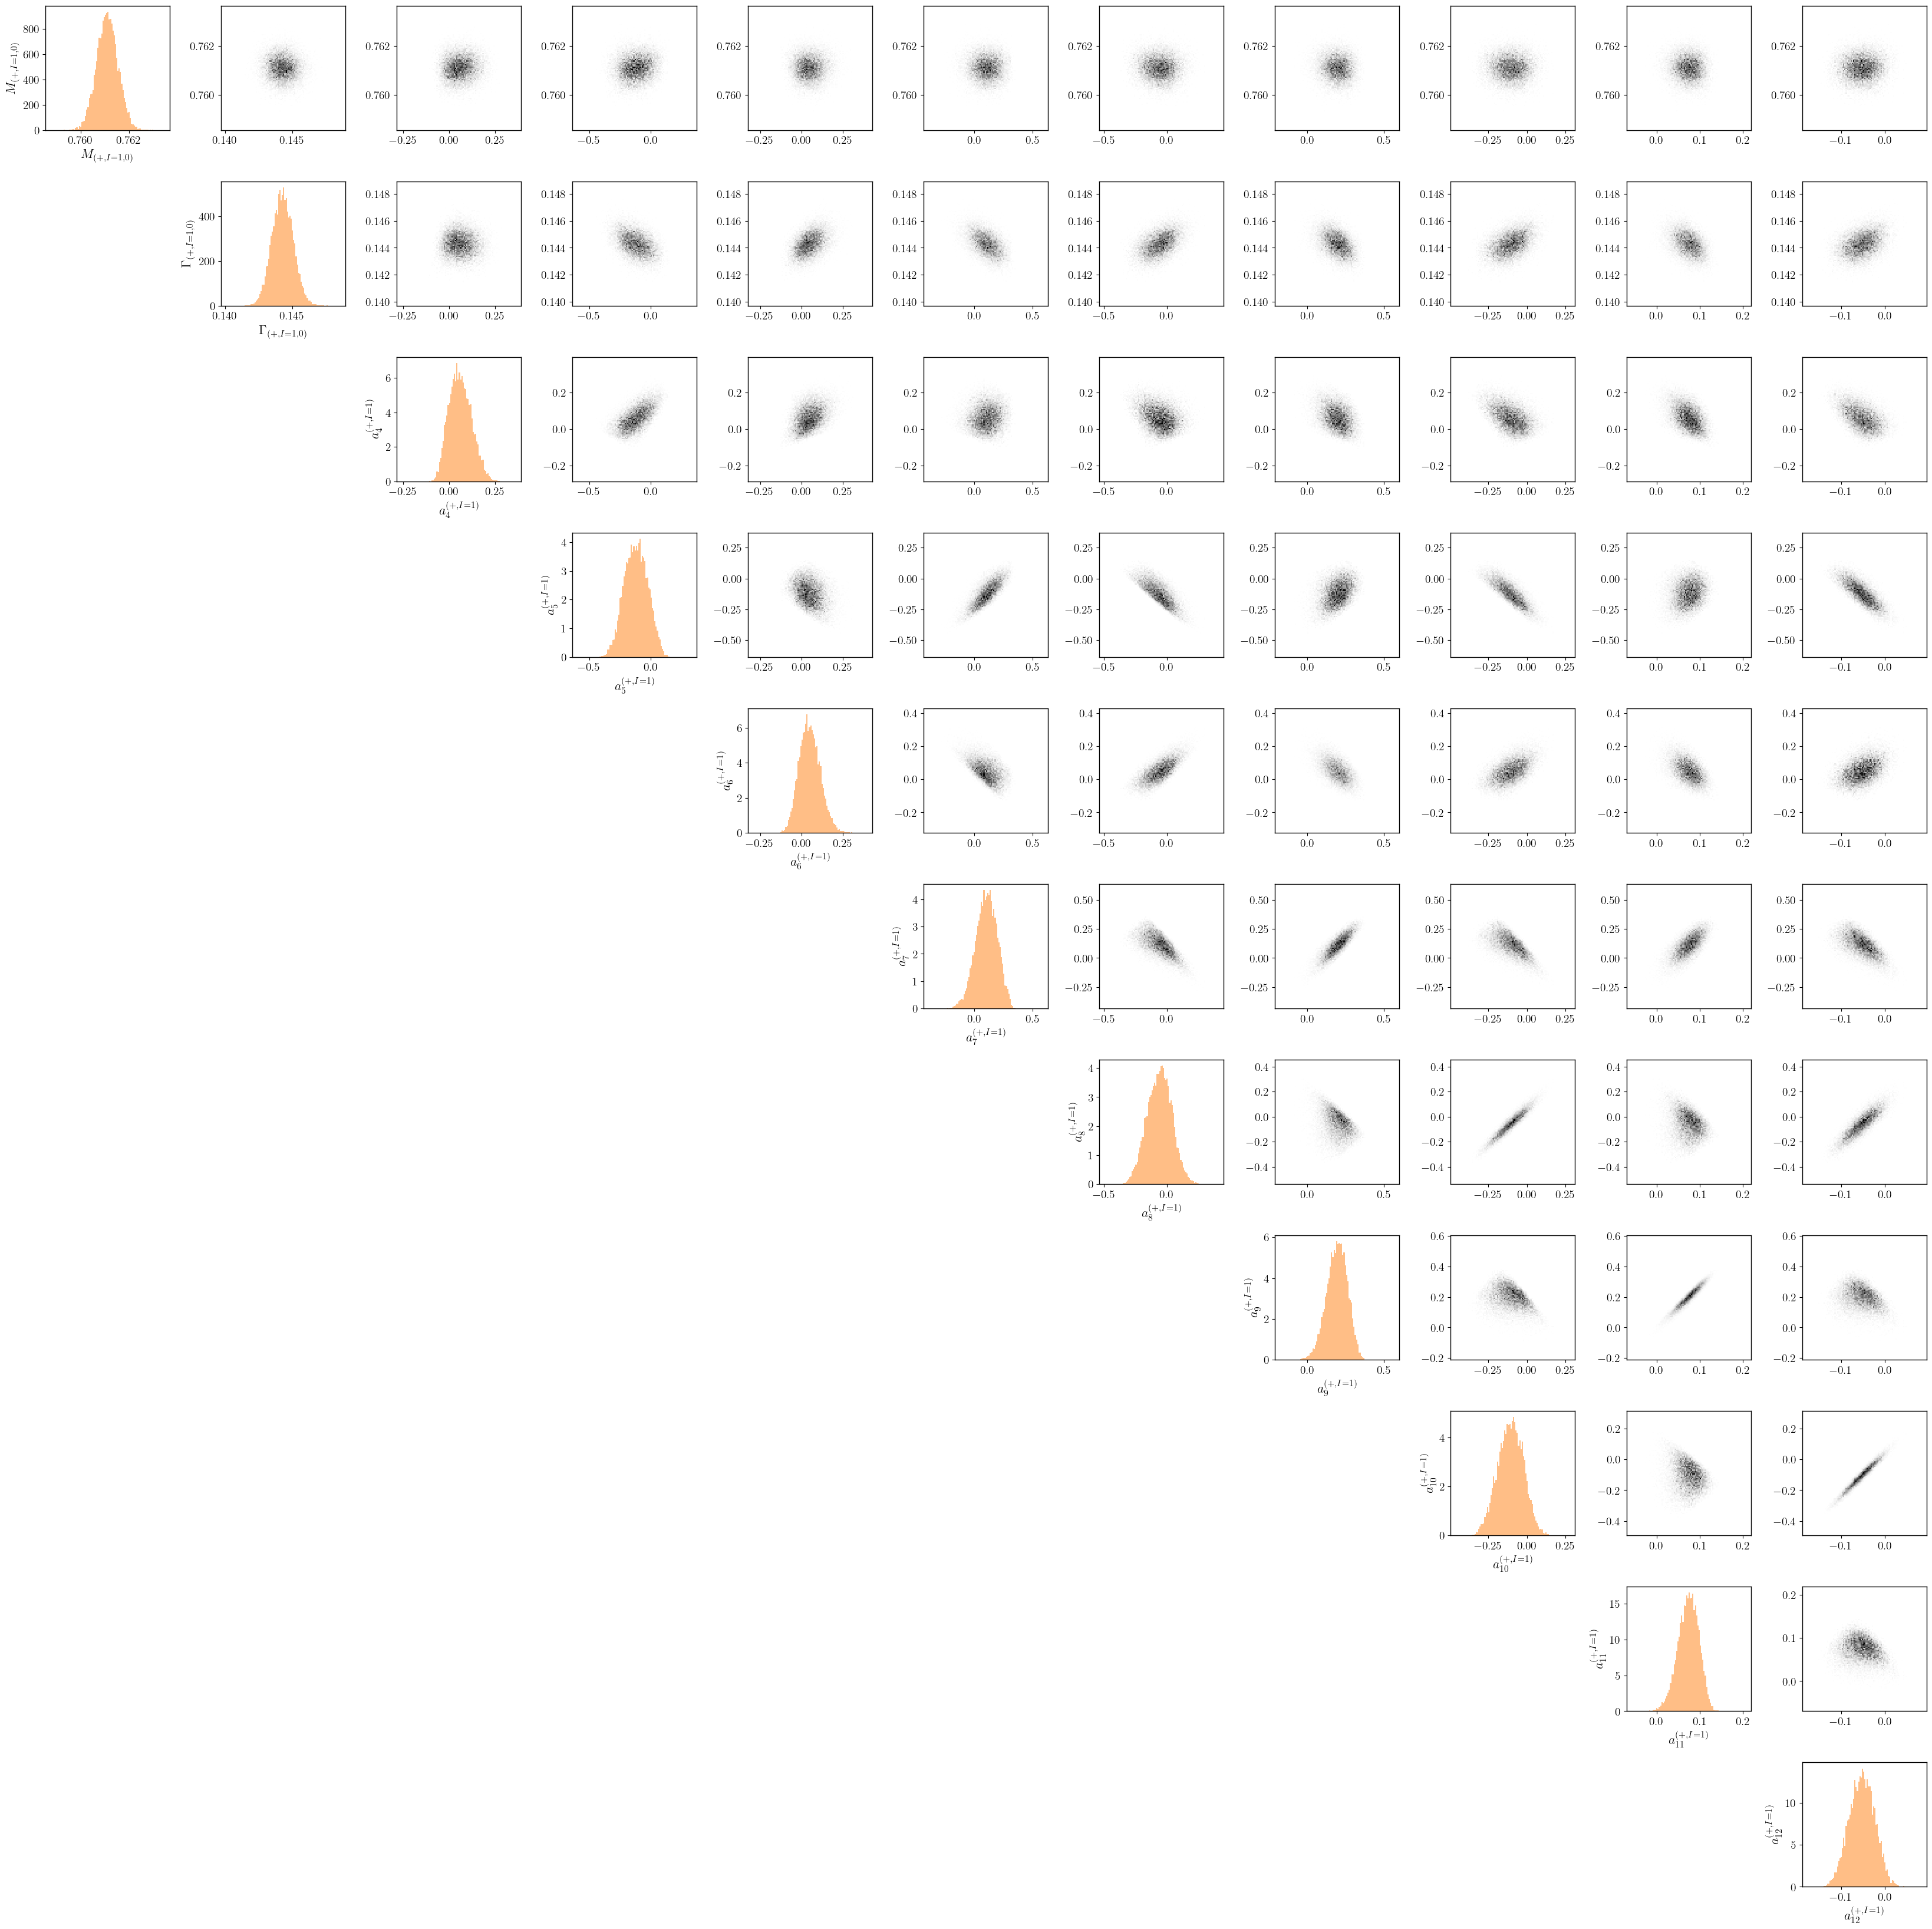

In [300]:
if not resample:
    eos.tasks.corner_plot(af, posterior, base_directory=BASE_DIRECTORY)

In [15]:
print(f"rho mass  = {np.average(f.samples[:,0], weights=f.weights):.4f} ± {wstd(f.samples[:,0], weights=f.weights):.4f}")
print(f"rho width = {np.average(f.samples[:,1], weights=f.weights):.4f} ± {wstd(f.samples[:,1], weights=f.weights):.4f}")

rho mass  = 0.7611 ± 0.0004
rho width = 0.1443 ± 0.0008


In [16]:
# Dispersive bound computation
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-dispersive-bound", base_directory=BASE_DIRECTORY)
preds = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-dispersive-bound'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order12/p…

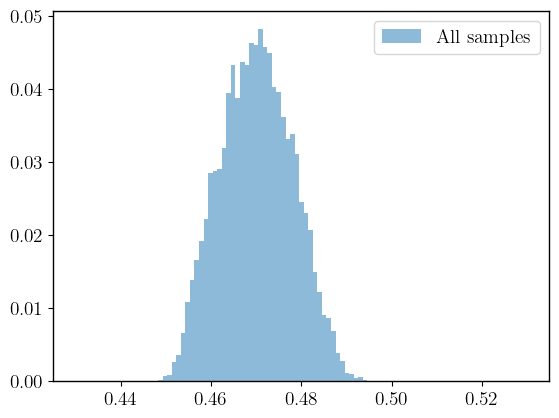

In [17]:
plt.hist(preds.samples, weights=preds.weights, bins=np.linspace(0.43,0.53,100), alpha=0.5, label='All samples')
plt.legend()
plt.show()

In [18]:
disp_values = np.array(preds.samples[:,0])
disp_mean   = np.average(disp_values, weights=preds.weights)
disp_std    = wstd(disp_values, weights=preds.weights)
print(f"Dispersive bound is {disp_mean:.4f} ± {disp_std:.4f}")

Dispersive bound is 0.4701 ± 0.0080


In [19]:
eos.tasks.predict_observables(af, posterior, "FF-fp2-I1-all", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order12/p…

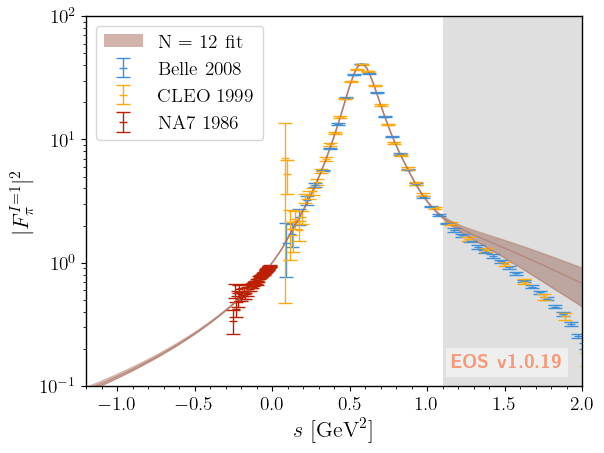

In [20]:
figure_args = {
'watermark': { 'position': 'lower right' },
'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-1.2, 2.0] },
    'yaxis': { 'label': r'$|F^{I=1}_\pi|^2$', 'range': [ 0.1, 100.0], 'scale': 'log' },
    'legend': { 'position': 'upper left' },
    'items': [
    { 'type': 'constraint', 'label': 'Belle 2008', 'color': colors[0],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2)',
        'constraints': '0->pipi::Abs{f_+}^2@Belle:2008C',
    },
    { 'type': 'constraint', 'label': 'CLEO 1999', 'color': colors[1],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2)',
        'constraints': '0->pipi::Abs{f_+}^2@CLEO:2000B',
    },
    { 'type': 'constraint', 'label': 'NA7 1986', 'color': colors[2],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2)',
        'constraints': '0->pipi::Abs{f_+}^2@NA7:1986A',
    },
    { 'type': 'uncertainty', 'label': 'N = 12 fit', 'color': colors[5],
        'variable': 'q2', 'range': [-1.2, 2.0], 'interpolation': 'cubic',
        'datafile': 'data/'+posterior+'/pred-FF-fp2-I1-all', 'resolution': 300
    },
    { 'type': 'band', 'color': 'gray', 'alpha': 0.25, 'x': [1.1, 2.0], 'y': [0.0, 100]}
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [21]:
eos.tasks.predict_observables(af, posterior, "FF-arg-fp-I1-timelike", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order12/p…

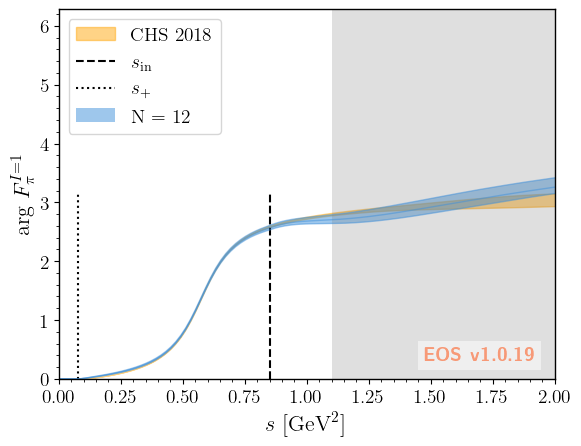

In [22]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [0.0, 2.0] },
    'yaxis': { 'label': r'arg $F^{I=1}_\pi$', 'range': [0.0 , 2*np.pi] },
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'N = 12', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-FF-arg-fp-I1-timelike', 'color': colors[0]
      },
      { 'type': 'band', 'color': 'gray', 'alpha': 0.25, 'x': [1.1, 2.0], 'y': [0.0, 2*np.pi]}
    ]
  }
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)

q2_over_mpisquared, phase, err = np.loadtxt("scripts/d11-central.txt", skiprows=1, unpack=True)
mpi = eos.Parameters()["mass::pi^+"].evaluate()
q2  = q2_over_mpisquared * mpi**2

figure._ax.fill_between(q2, phase-err, phase+err, label="CHS 2018", alpha=0.5, color=colors[1])
figure._ax.plot([sIn, sIn], [0.0, np.pi], color='k', linestyle='--', label= r'$s_\mathrm{in}$')
figure._ax.plot([sPlus, sPlus], [0.0, np.pi], color='k', linestyle=':', label= r'$s_+$')
figure._ax.legend(loc="upper left")

figure.draw()

In [23]:
get_gof(analysis, start_point)
analysis.parameters.dump('data/'+posterior+'/mode-default/parameters.yaml')

Handling item to plot 0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026 in the complex plane
Overriding parameters from file
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,2)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(0,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(0,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,2)@KSvD2025' with central value '0'
[parameters.override] Overriding existing p

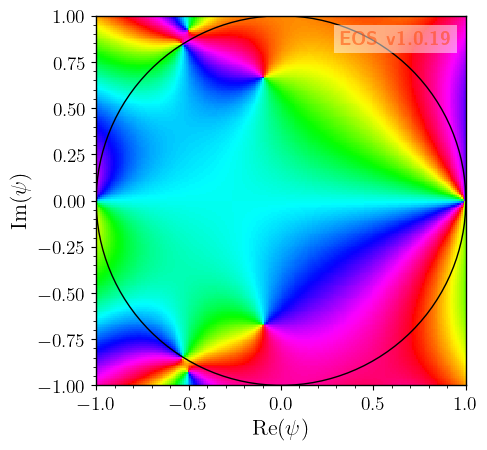

In [26]:
figure_args = {
'plot': {
    'xaxis': { 'label': r'$\mathrm{Re}(\psi)$', 'range': [-1.0, 1.0] },
    'yaxis': { 'label': r'$\mathrm{Im}(\psi)$', 'range': [-1.0, 1.0] },
    # 'legend': { 'position': 'upper left' },
    'items': [
    { 'type': 'complex-plane', 'label': 'N = 11 fit', 'colormap': 'hsv',
        'variables': ["Re{psi}", "Im{psi}"], 'observable': "0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026",
        'fixed_parameters_from_file': 'data/'+posterior+'/mode-default/parameters.yaml', 'resolution': 200
    }
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()
circle = plt.Circle((0, 0), 1.0, color='k', fill=False)
figure._ax.add_patch(circle)
figure._ax.set_aspect("equal", adjustable="box")

In [14]:
eos.tasks.predict_observables(af, posterior, "real-partial-wave-I1", base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables(af, posterior, "imag-partial-wave-I1", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order12/p…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order12/p…

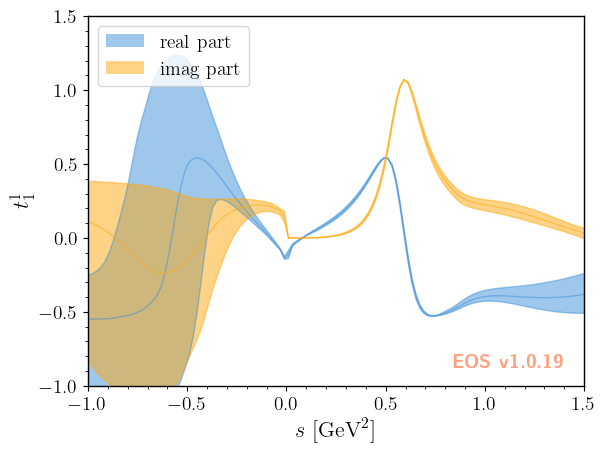

In [15]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-1.0, 1.5] },
    'yaxis': { 'label': '$t_1^1$',  'range': [-1.0, 1.5]},
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'real part', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-real-partial-wave-I1'
      },
      { 'type': 'uncertainty', 'label': 'imag part', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-imag-partial-wave-I1'
      },
    ]
  }
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

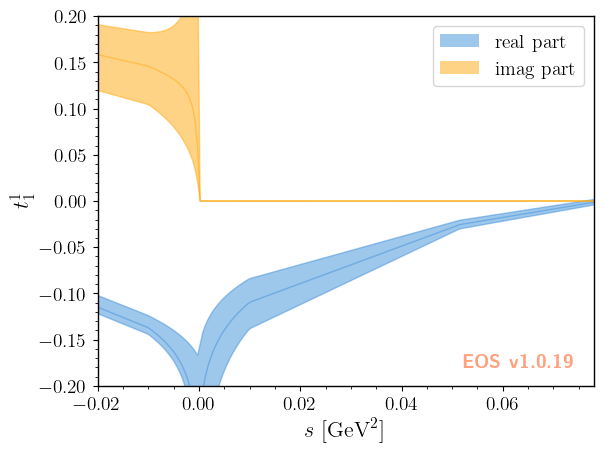

In [23]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-0.02, sPlus] },
    'yaxis': { 'label': '$t_1^1$',  'range': [-0.2, 0.2]},
    'legend': { 'position': 'upper right' },
    'items': [
      { 'type': 'uncertainty', 'label': 'real part', 'interpolation': 'linear', 'resolution': 10000,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-real-partial-wave-I1'
      },
      { 'type': 'uncertainty', 'label': 'imag part', 'interpolation': 'linear', 'resolution': 10000,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-imag-partial-wave-I1'
      },
    ]
  }
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [17]:
# Analytic value of a11
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-scattering-length-params", base_directory=BASE_DIRECTORY)
sl_params = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-scattering-length-params'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order12/p…

In [18]:
a11_values = np.array(list(map(a11_calculator, sl_params.samples)))* mpi**2
a11_mean   = np.average(a11_values, weights=sl_params.weights)
a11_std    = wstd(a11_values, weights=sl_params.weights)
print(f"a11 = {a11_mean:.4f} ± {a11_std:.4f}")

a11 = 0.0176 ± 0.0026


In [19]:
# Charge radius
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-pion-charge-radius-param", base_directory=BASE_DIRECTORY)
fprime_values = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-pion-charge-radius-param'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order12/p…

In [20]:
charge_radius_squared_values = np.array(list(map(charge_radius_squared_calculator, fprime_values.samples[:, 0])))
radius_mean = np.average(charge_radius_squared_values, weights=fprime_values.weights)
radius_std  = wstd(charge_radius_squared_values, weights=fprime_values.weights)
print(f"<r^2> = {radius_mean:.4f} ± {radius_std:.4f} fm^2")

<r^2> = 0.4323 ± 0.0047 fm^2


In [65]:
# Residue at the rho pole
eos.tasks.predict_observables(af, posterior, "re-rho-residue-psi", base_directory=BASE_DIRECTORY)
re_res_psi = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-re-rho-residue-psi'))
eos.tasks.predict_observables(af, posterior, "im-rho-residue-psi", base_directory=BASE_DIRECTORY)
im_res_psi = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-im-rho-residue-psi'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order12/p…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order12/p…

In [66]:
re_res = re_res_psi.samples[:,0]
im_res = im_res_psi.samples[:,0]
M      = f.samples[:,0]
Gamma  = f.samples[:,1]

print(len(re_res), len(im_res), len(M), len(Gamma)) # check that they have the same length

17727 17727 17727 17727


In [67]:
data = []

for r, i, m, g in zip(re_res, im_res, M, Gamma):
    data.append([r, i, m, g])

with open("residues_psi_order12.wl", "w") as file:
    lines = [f"{{{r}, {i}, {m}, {g}}}" for r, i, m, g in data]
    file.write("{\n" + ",\n".join(lines) + "\n}")

In [ ]:
with open("residues_s_order12.wl") as file:
    text = file.read()

# Replace Mathematica braces with Python brackets
text = text.replace("{", "[").replace("}", "]")

data = ast.literal_eval(text)

FileNotFoundError: [Errno 2] No such file or directory: 'residues_s_order11.wl'

In [ ]:
res_s       = np.array([re + 1j * im for re, im in data])
res_s_mean  = np.average(res_s, weights=f.weights)
radius_std  = wstd(res_s, weights=f.weights)
print(f"residue at s_rho is ({np.real(res_s_mean):.4f} ± {np.real(radius_std):.4f}) + i * ({np.imag(res_s_mean):.4f} ± {np.imag(radius_std):.4f})")

residue at s_rho is (-0.6812 ± 0.0076) + i * (0.1773 ± 0.0181)


In [ ]:
# Computing g_{rho pi pi} and g_{rho gamma}
f_at_s_rho       = np.array([get_f_rho(s, analysis) for s in f.samples])
f_at_s_rho_value = f_at_s_rho[:,0] + 1j * f_at_s_rho[:,1]

In [ ]:
s_rho       = (M - 1j * Gamma / 2)**2
g_rho_gamma = np.sqrt(24j * np.pi * s_rho / f_at_s_rho_value / res_s / (np.sqrt(1 - sPlus / s_rho))**3)
g_rho_pi_pi = - res_s / s_rho * g_rho_gamma

In [ ]:
g_rho_gamma_mean = np.average(g_rho_gamma, weights=f.weights)
g_rho_gamma_std  = wstd(g_rho_gamma, weights=f.weights)
print(f"g_rho_gamma =  ({np.real(g_rho_gamma_mean):.4f} ± {np.real(g_rho_gamma_std):.4f}) + i * ({np.imag(g_rho_gamma_mean):.4f} ± {np.imag(g_rho_gamma_std):.4f})")

g_rho_pi_pi_mean = np.average(g_rho_pi_pi, weights=f.weights)
g_rho_pi_pi_std  = wstd(g_rho_pi_pi, weights=f.weights)
print(f"g_rho_pi_pi =  ({np.real(g_rho_pi_pi_mean):.4f} ± {np.real(g_rho_pi_pi_std):.4f}) + i * ({np.imag(g_rho_pi_pi_mean):.4f} ± {np.imag(g_rho_pi_pi_std):.4f})")

g_rho_gamma = 4.8573-0.5807j ± 0.0043+0.0032j
g_rho_pi_pi = 5.7400+0.0110j ± 0.0272+0.1512j
